<a href="https://colab.research.google.com/github/josuequispe-boop/Predicci-n-multi-profundidad-de-la-humedad-del-suelo---Ancash/blob/main/CodFINAL_Prediccion_humedad_suelo_CDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Lectura de los archivos ya tratados

In [ ]:
# Importanto librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [ ]:
# ruta de los archivos
ruta1 = '/content/drive/MyDrive/Ciencias de datos/Base de datos/Est_1_final_procesado.csv'
ruta2 = '/content/drive/MyDrive/Ciencias de datos/Base de datos/Est_2_final_procesado.csv'
ruta3 = '/content/drive/MyDrive/Ciencias de datos/Base de datos/Est_3_final_procesado.csv'

# lectura de los archivos
df1 = pd.read_csv(ruta1)
df2 = pd.read_csv(ruta2)
df3 = pd.read_csv(ruta3)
df1.head(10)
df1.tail()
#

,fecha,Precipitación,Temp_Max,Temp_Min,Temp_Prom,Evapotranspiración,Humedad Relativa,HUMEDAD SUELO-20,HUMEDAD SUELO-60,HUMEDAD SUELO-100
1473,2023-08-27,0.0,20.6,1.1,8.420833,0.000000e+00,61.788887,3.8,3.2,1.4
1474,2023-08-28,0.0,21.1,1.7,8.608333,0.000000e+00,63.633372,3.8,3.2,1.4
1475,2023-08-29,0.0,24.7,1.6,9.387500,-3.880511e-08,67.228068,3.8,3.2,1.4
1476,2023-08-30,0.2,23.5,2.3,9.204167,-8.731149e-08,63.191455,3.7,3.2,1.4
1477,2023-08-31,0.0,3.3,3.3,3.300000,0.000000e+00,70.348979,3.7,3.2,1.4


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


In [ ]:
#convertir a fecha
df1['fecha'] = pd.to_datetime(df1['fecha'])
df2['fecha'] = pd.to_datetime(df2['fecha'])
df3['fecha'] = pd.to_datetime(df3['fecha'])

In [ ]:
df11 = df1.set_index('fecha')
df22 = df2.set_index('fecha')
df33 = df3.set_index('fecha')

## Análisis de Autocorrelación de humedad de suelo


### Análisis de Autocorrelación Estacion 1


In [ ]:
print(f"Tipo de índice: {type(df11.index)}")
print(f"Dtype del índice: {df11.index.dtype}")

Tipo de índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Dtype del índice: datetime64[ns]


In [ ]:
def graficar_acf_pacf_humedad(df):
    """
    Genera gráficos de ACF y PACF para la humedad del suelo
    a profundidades de 20 cm, 60 cm y 100 cm.
    """
    # Lista de las variables exactas que contiene tu archivo
    variables = ['HUMEDAD SUELO-20', 'HUMEDAD SUELO-60', 'HUMEDAD SUELO-100', 'Precipitación', 'Evapotranspiración']

    for var in variables:
        # Verificar si la variable existe en el DataFrame para evitar errores
        if var in df.columns:
            # Resuestreo diario y eliminación de valores nulos
            datos_diarios = df[var].resample('D').mean()

            # Crear la figura para la variable actual
            fig, ejes = plt.subplots(1, 2, figsize=(14, 4))

            # Gráfico de Autocorrelación (ACF)
            plot_acf(datos_diarios, lags=24, ax=ejes[0])
            ejes[0].set_title(f'Función de Autocorrelación (ACF) - {var} ')
            ejes[0].set_xlabel('Rezago (días)')

            # Gráfico de Autocorrelación Parcial (PACF)
            plot_pacf(datos_diarios, lags=24, ax=ejes[1])
            ejes[1].set_title(f'Función de Autocorrelación Parcial (PACF) - {var} ')
            ejes[1].set_xlabel('Rezago (días)')

            plt.tight_layout()
            plt.show()

            print(f"--- Análisis para {var} cm ---")
            print("ACF: muestra correlación en rezago ")
            print("PACF: muestra la relación directa eliminando efectos intermedios\n")


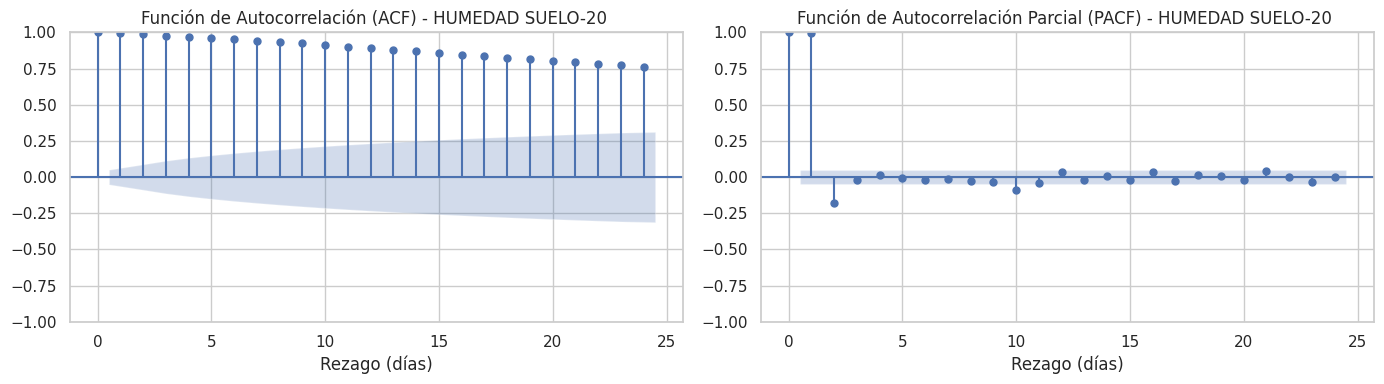

--- Análisis para HUMEDAD SUELO-20 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



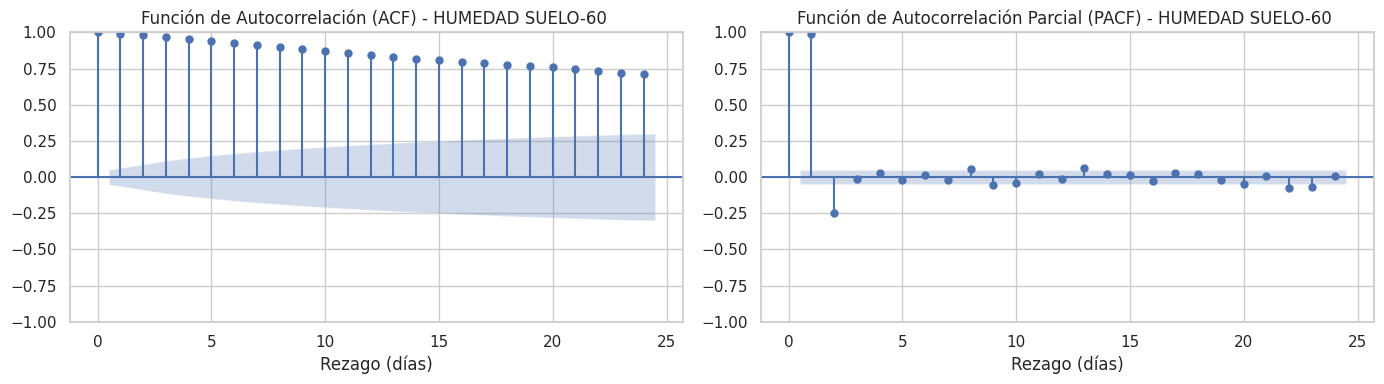

--- Análisis para HUMEDAD SUELO-60 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



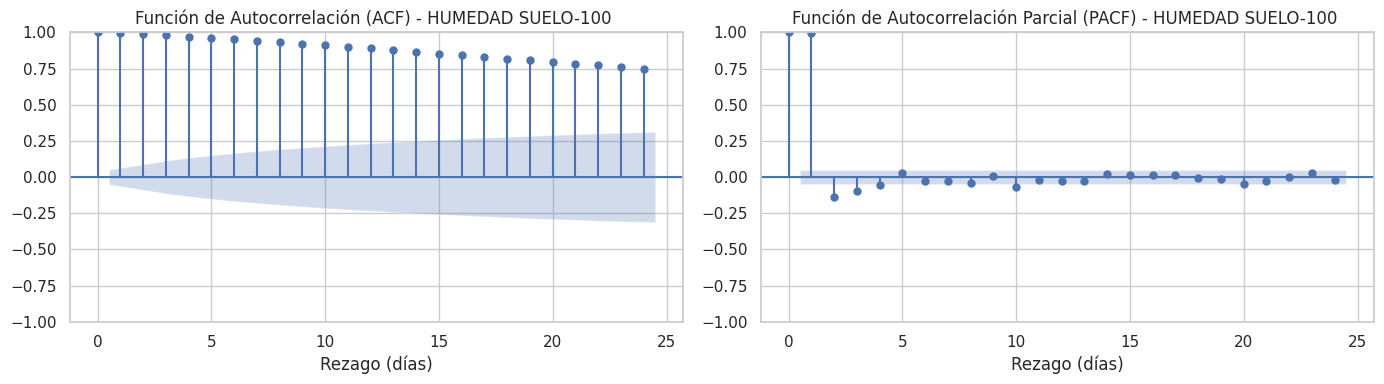

--- Análisis para HUMEDAD SUELO-100 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



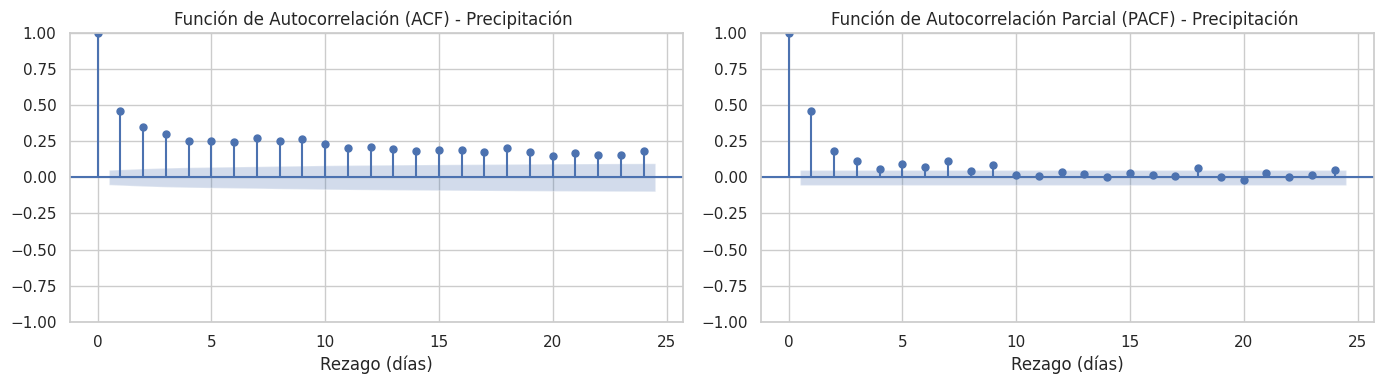

--- Análisis para Precipitación cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



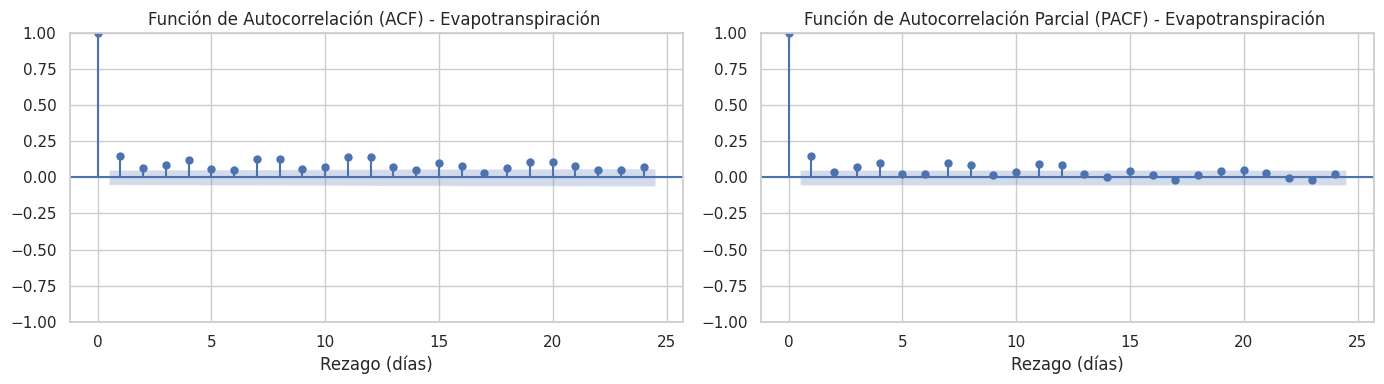

--- Análisis para Evapotranspiración cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



In [ ]:
graficar_acf_pacf_humedad(df11)

### Análisis de Autocorrelación Estacion 2

In [ ]:
# insertar fecha a indice -  ESTACIÓN 2
df22 = df2.set_index('fecha')

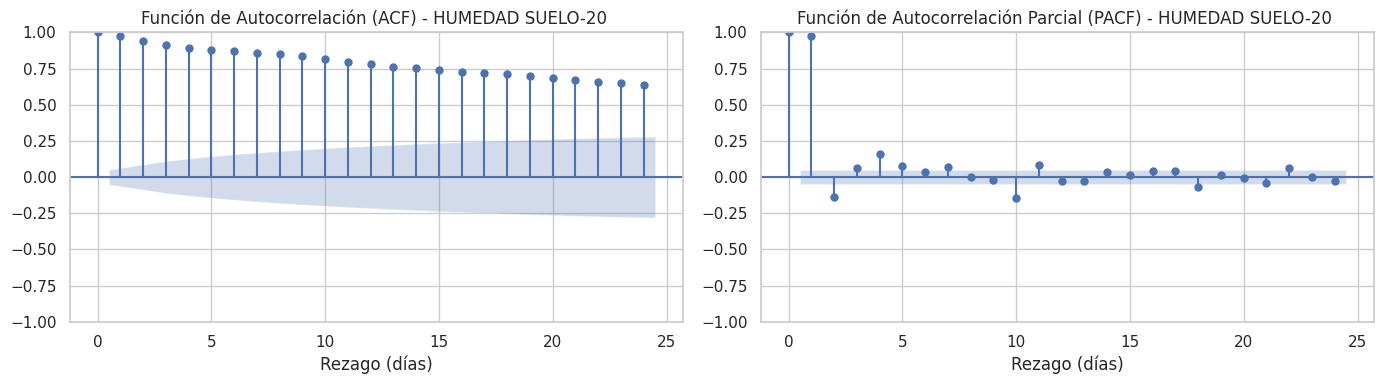

--- Análisis para HUMEDAD SUELO-20 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



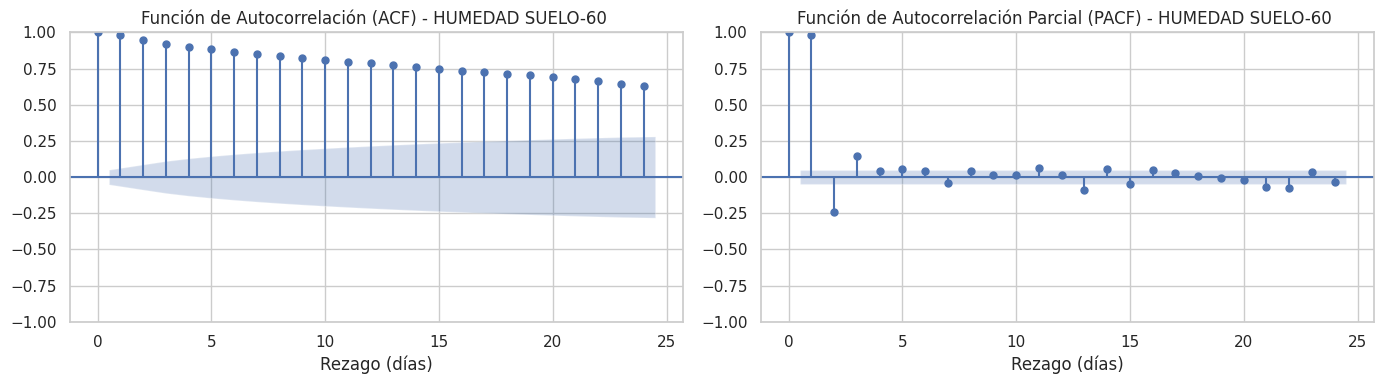

--- Análisis para HUMEDAD SUELO-60 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



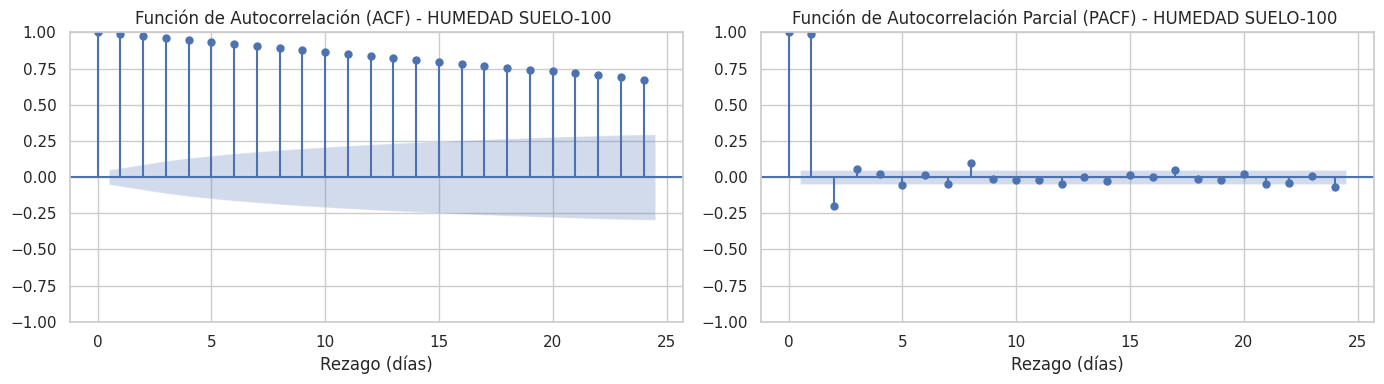

--- Análisis para HUMEDAD SUELO-100 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



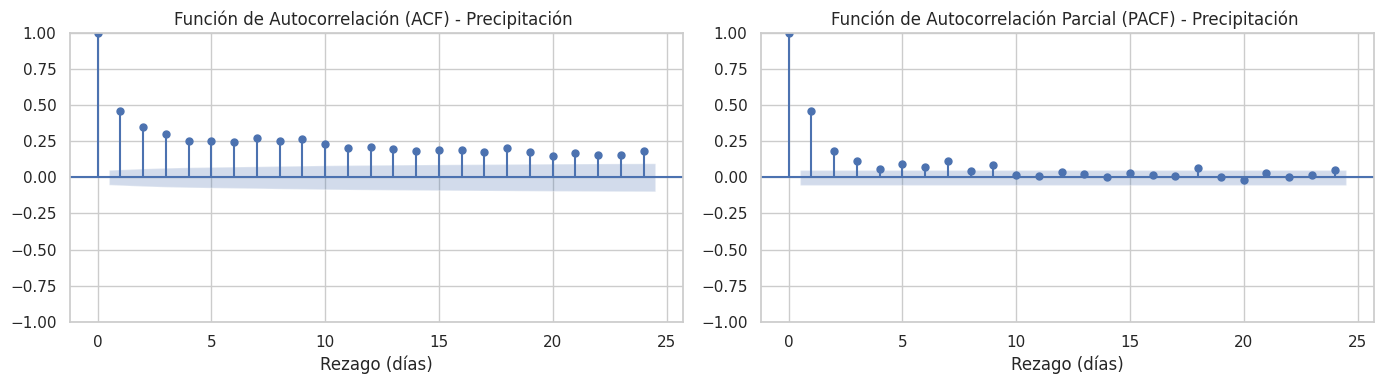

--- Análisis para Precipitación cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



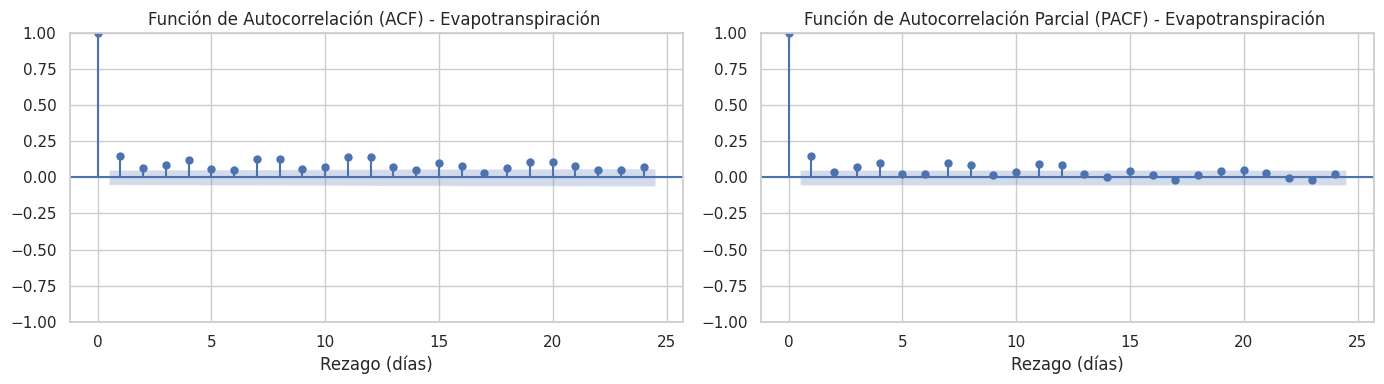

--- Análisis para Evapotranspiración cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



In [ ]:
graficar_acf_pacf_humedad(df22)

### Análisis de Autocorrelación Estacion 3

In [ ]:
df33 = df3.set_index('fecha')

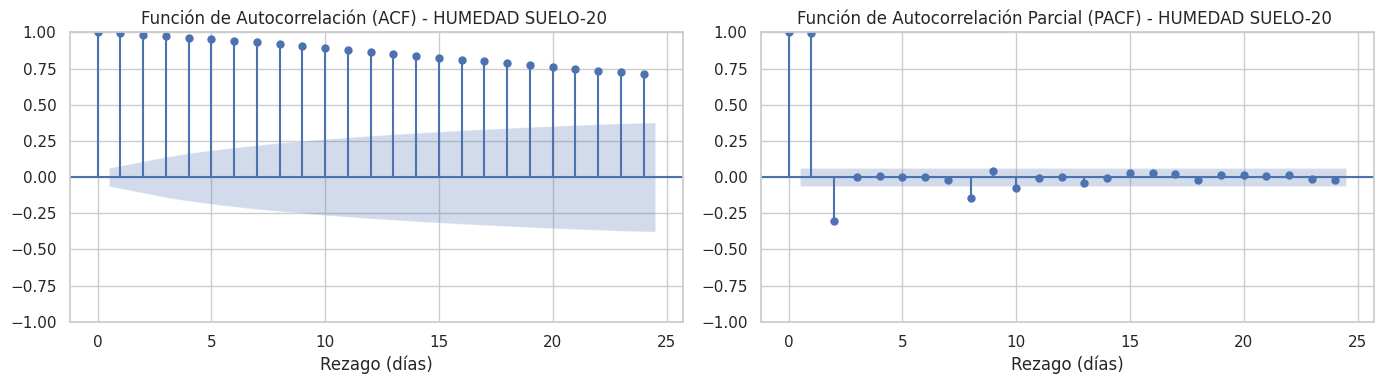

--- Análisis para HUMEDAD SUELO-20 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



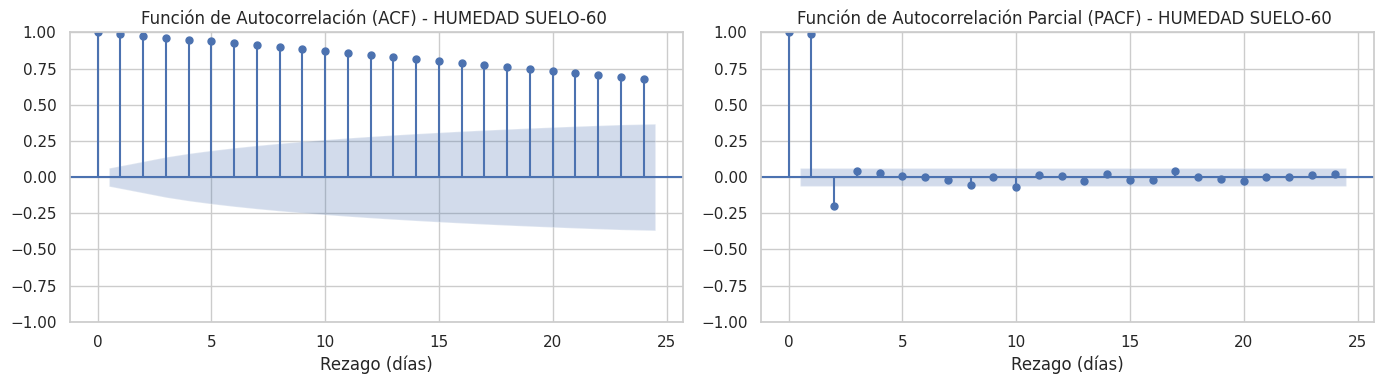

--- Análisis para HUMEDAD SUELO-60 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



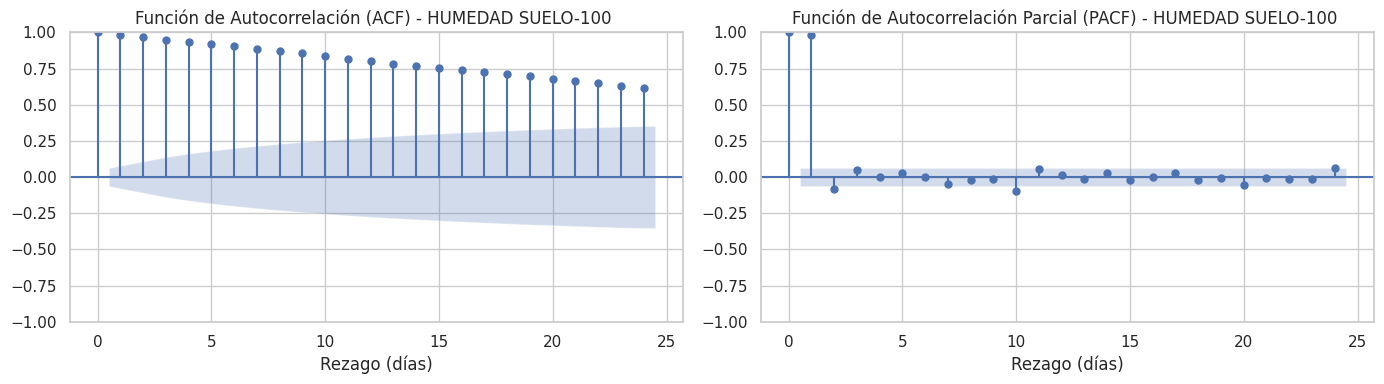

--- Análisis para HUMEDAD SUELO-100 cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



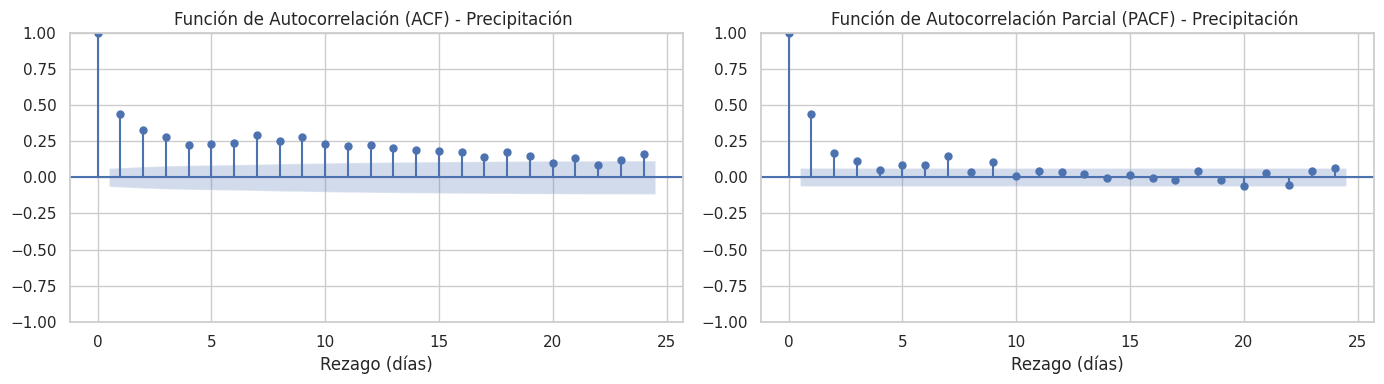

--- Análisis para Precipitación cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1490: ValueWarning:

Matrix is singular. Using pinv.



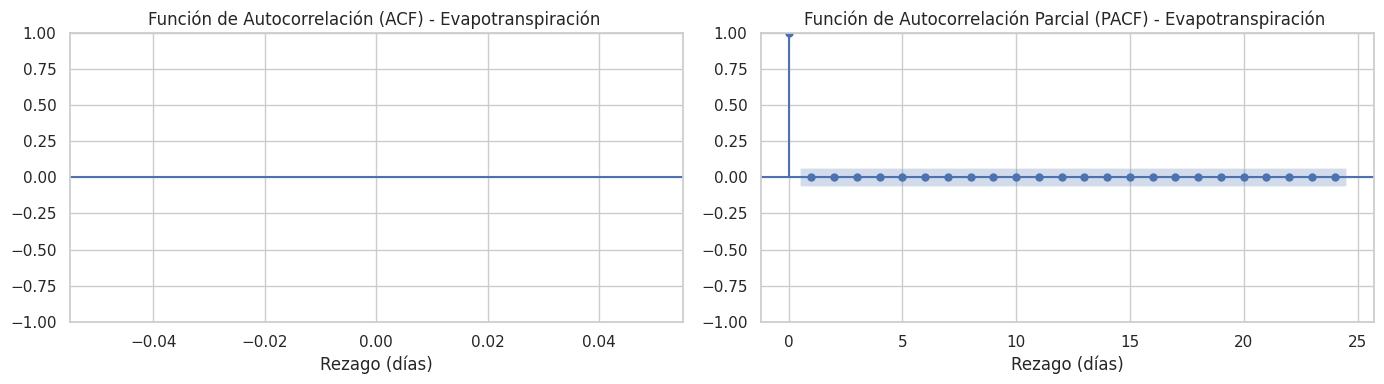

--- Análisis para Evapotranspiración cm ---
ACF: muestra correlación en rezago 
PACF: muestra la relación directa eliminando efectos intermedios



In [ ]:
graficar_acf_pacf_humedad(df33)

## Selección de Variables Predictores y Target

### Estación 1

Creación de variables rezagadas (precipitación, humedad a 20 cm)



In [ ]:
df_diario = df11
df_diario

,Precipitación,Temp_Max,Temp_Min,Temp_Prom,Evapotranspiración,Humedad Relativa,HUMEDAD SUELO-20,HUMEDAD SUELO-60,HUMEDAD SUELO-100
fecha,,,,,,,,,
2019-08-15,0.0,20.6,0.5,7.917361,-3.880511e-08,51.167792,5.3,3.0,1.0
2019-08-16,0.0,20.7,-0.5,8.312500,9.701277e-09,42.618698,5.2,3.0,1.0
2019-08-17,0.0,22.4,0.4,8.788542,-3.880511e-08,42.100011,5.2,3.0,1.1
2019-08-18,0.0,22.4,1.3,9.153819,0.000000e+00,52.929224,5.2,3.0,1.0
2019-08-19,0.0,21.9,1.9,9.052083,0.000000e+00,59.205051,5.2,3.0,1.0
...,...,...,...,...,...,...,...,...,...
2023-08-27,0.0,20.6,1.1,8.420833,0.000000e+00,61.788887,3.8,3.2,1.4
2023-08-28,0.0,21.1,1.7,8.608333,0.000000e+00,63.633372,3.8,3.2,1.4
2023-08-29,0.0,24.7,1.6,9.387500,-3.880511e-08,67.228068,3.8,3.2,1.4


In [ ]:


# =====================================================================
# 1. CREACIÓN DE CARACTERÍSTICAS (FEATURES) - USANDO SOLO VARIABLES METEOROLOGICAS
# =====================================================================
def pred_var_meteor(df_diario):

  # Rezagos y acumulados meteorológicos (el agua tarda en infiltrarse)
  df_diario['lluvia_ayer'] = df_diario['Precipitación'].shift(1)
  df_diario['lluvia_acum_3d'] = df_diario['Precipitación'].shift(1).rolling(3).sum()
  df_diario['lluvia_acum_5d'] = df_diario['Precipitación'].rolling(5).sum()
  #df_diario['lluvia_acum_7d'] = df_diario['Precipitación'].rolling(7).sum()

  #df_diario['et_ayer'] = df_diario['Evapotranspiración'].shift(1)


  # Limpiar las filas con valores nulos generados por los rezagos/ventanas móviles
  df_diario = df_diario.dropna()

  # =====================================================================
  # 2. DEFINICIÓN DE LISTAS DE PREDICTORES (COLUMNAS ACTUALIZADAS)
  # =====================================================================

  # Lista corregida y declarada para el modelo de 20 cm
  predictores_20cm = [
      #'h20_ayer', 'h20_promedio_3d',
      'Precipitación', 'lluvia_ayer', 'lluvia_acum_3d',
      'Evapotranspiración', #'et_ayer',
      'Temp_Prom', 'Humedad Relativa', 'Temp_Max', 'Temp_Min'
  ]

  predictores_60cm = [
    # 'h20_actual', 'h20_ayer',
      'Precipitación', 'lluvia_acum_5d',
      'Evapotranspiración',
      'Temp_Prom', 'Humedad Relativa', 'Temp_Max', 'Temp_Min'
  ]

  predictores_100cm = [
      #'h20_actual', 'h20_ayer',
      'lluvia_acum_5d', #'lluvia_acum_7d',
      'Evapotranspiración', 'Temp_Prom','Temp_Max', 'Temp_Min'
  ]
  return df_diario, predictores_20cm, predictores_60cm, predictores_100cm

# ======================================================================
# PARA PREDICCION ESCALONADA
# =====================================================================

def generar_features_base(df_diario):

    df = df_diario.copy()

    # Variables del sensor real de 20 cm
    df['h20_actual'] = df['HUMEDAD SUELO-20']
    df['h20_ayer'] = df['HUMEDAD SUELO-20'].shift(1)
    df['h20_promedio_3d'] = df['HUMEDAD SUELO-20'].shift(1).rolling(3).mean()

    # Rezagos y acumulados meteorológicos
    df['lluvia_ayer'] = df['Precipitación'].shift(1)
    df['lluvia_acum_3d'] = df['Precipitación'].shift(1).rolling(3).sum()
    df['lluvia_acum_5d'] = df['Precipitación'].rolling(5).sum()
    df['et_ayer'] = df['Evapotranspiración'].shift(1)

    return df.dropna()

# =====================================================================
# 2. DEFINICIÓN DINÁMICA DE PREDICTORES
# =====================================================================
def obtener_listas_predictores():

    predictores_60cm = [
        'h20_actual', 'h20_ayer', 'h20_promedio_3d', 'lluvia_acum_3d',
        'Precipitación', 'lluvia_acum_5d', 'Evapotranspiración',
        'Temp_Prom', 'Humedad Relativa', 'Temp_Max', 'Temp_Min'
    ]

    predictores_100cm = [
        'h60_predicho',  # Generada por el escalón anterior
        'h20_actual', 'h20_ayer',
        'lluvia_acum_5d', 'Evapotranspiración',
        'Temp_Prom', 'Temp_Max', 'Temp_Min', 'Humedad Relativa'
    ]

    return predictores_60cm, predictores_100cm

In [ ]:
# =====================================================================
# 3. NÚCLEO DE ENTRENAMIENTO (REUTILIZABLE PARA CUALQUIER MODELO)
# =====================================================================
def entrenar_y_evaluar(X, y, algoritmo, test_size=0.2, random_state=42):

    # Split secuencial (shuffle=False recomendado para series temporales)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=False
    )

    # Entrenar el modelo recibido
    algoritmo.fit(X_train, y_train)

    # Predicciones de test (para métricas)
    predicciones_test = algoritmo.predict(X_test)

    return algoritmo, y_test, predicciones_test

In [ ]:
# =====================================================================
# 4. ORQUESTADOR DEL FLUJO ESCALONADO
# =====================================================================
def ejecutar_pipeline_escalonado(df_inicial, modelo_60cm, modelo_100cm):
    """
    Orquesta todo el proceso en cascada: procesa features, entrena 60cm,
    inyecta la predicción en el DataFrame y entrena 100cm.
    """
    # Diccionarios para almacenar los outputs
    modelos_entrenados = {}
    resultados_test = {}

    # Paso 1: Preparar los datos base
    df_trabajo = generar_features_base(df_inicial)
    pred_60, pred_100 = obtener_listas_predictores()

    # --- ESCALÓN 60 CM ---
    print(">> Procesando Escalón: 60cm...")
    X_60 = df_trabajo[pred_60].values
    y_60 = df_trabajo['HUMEDAD SUELO-60'].values

    mod_60, y_test_60, pred_test_60 = entrenar_y_evaluar(X_60, y_60, modelo_60cm)

    modelos_entrenados['60cm'] = mod_60
    resultados_test['60cm'] = {'y_true': y_test_60, 'y_pred': pred_test_60}

    # IMPORTANTE: Predicción del dataset completo para habilitar el siguiente escalón
    df_trabajo['h60_predicho'] = mod_60.predict(X_60)

    # --- ESCALÓN 100 CM ---
    print(">> Procesando Escalón: 100cm...")
    X_100 = df_trabajo[pred_100].values
    y_100 = df_trabajo['HUMEDAD SUELO-100'].values

    mod_100, y_test_100, pred_test_100 = entrenar_y_evaluar(X_100, y_100, modelo_100cm)

    modelos_entrenados['100cm'] = mod_100
    resultados_test['100cm'] = {'y_true': y_test_100, 'y_pred': pred_test_100}

    return modelos_entrenados, resultados_test

In [ ]:
df_diari = pred_var_meteor(df_diario)
df_diari[2]

['Precipitación',
 'lluvia_acum_5d',
 'Evapotranspiración',
 'Temp_Prom',
 'Humedad Relativa',
 'Temp_Max',
 'Temp_Min']

In [ ]:
df_diari[0][df_diari[1]]

,Precipitación,lluvia_ayer,lluvia_acum_3d,Evapotranspiración,Temp_Prom,Humedad Relativa,Temp_Max,Temp_Min
fecha,,,,,,,,
2019-08-19,0.0,0.0,0.0,0.000000e+00,9.052083,59.205051,21.9,1.9
2019-08-20,0.0,0.0,0.0,0.000000e+00,8.722569,62.448273,21.3,1.8
2019-08-21,0.0,0.0,0.0,0.000000e+00,8.706250,70.951209,19.7,2.0
2019-08-22,0.0,0.0,0.0,0.000000e+00,9.295486,62.430177,20.8,1.3
2019-08-23,0.0,0.0,0.0,0.000000e+00,8.002778,60.419529,19.5,1.0
...,...,...,...,...,...,...,...,...
2023-08-27,0.0,0.0,0.0,0.000000e+00,8.420833,61.788887,20.6,1.1
2023-08-28,0.0,0.0,0.0,0.000000e+00,8.608333,63.633372,21.1,1.7
2023-08-29,0.0,0.0,0.0,-3.880511e-08,9.387500,67.228068,24.7,1.6


In [ ]:

# 3. ASIGNANDO LAS VARIABLES PREDICTORAS A X | y
# ==========================================

def conf_model(df, con_20cm):
  if con_20cm == 'Si':
    df_diario = pred_completo(df)
    config_modelos = {
        'Humedad 20cm (Predicción)': {
            'X': df_diario[0][df_diario[1]].values,
            'y': df_diario[0]['HUMEDAD SUELO-20'].values
        },
        'Humedad 60cm (Sensor Virtual)': {
            'X': df_diario[0][df_diario[2]].values,
            'y': df_diario[0]['HUMEDAD SUELO-60'].values
        },
        'Humedad 100cm (Sensor Virtual)': {
            'X': df_diario[0][df_diario[3]].values,
            'y': df_diario[0]['HUMEDAD SUELO-100'].values
        }
    }
  else:
    df_diario = pred_var_meteor(df)
    config_modelos = {
        'Humedad 20cm (Predicción)': {
            'X': df_diario[0][df_diario[1]].values,
            'y': df_diario[0]['HUMEDAD SUELO-20'].values
        },
        'Humedad 60cm (Sensor Virtual)': {
            'X': df_diario[0][df_diario[2]].values,
            'y': df_diario[0]['HUMEDAD SUELO-60'].values
        },
        'Humedad 100cm (Sensor Virtual)': {
            'X': df_diario[0][df_diario[3]].values,
            'y': df_diario[0]['HUMEDAD SUELO-100'].values
        }
    }
  return config_modelos

## Entrenamiento de Modelos

### Predicción de humedad basado solo con variables meteorologicos - **EJEMPLO CON RANDOM FOREST**

Se realiza este ejemplo para verificar si el modelopredice correctamente la humedad de 20 cm solo con variables meteorologicas, sin tomar en cuentas variables de humedad de suelo. Y como se obervo, las metricas nos indican que un modelo regular al predecir, con un 50 % de confiabilidad.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#### Predicción de humedad de suelo - Estación 1

In [ ]:
config_modelos = conf_model(df_diario, 'No')

In [ ]:
# Diccionario para guardar los modelos entrenados
modelos_entrenados = {}

for nombre, datos in config_modelos.items():
    X = datos['X']
    y = datos['y']

    # División en entrenamiento (80%) y prueba (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    # Inicializar y entrenar el modelo
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Guardar modelo en el diccionario
    modelos_entrenados[nombre] = rf

    # Predicciones de prueba
    predicciones = rf.predict(X_test)

    # Cálculo de métricas
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    # Mostrar resultados
    print(f"=== {nombre} ===")
    print(f"R² Score (Precisión): {r2:.4f}")
    print(f"Error Medio Absoluto (MAE): {mae:.4f}")
    print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
    print("-" * 40)

=== Humedad 20cm (Predicción) ===
R² Score (Precisión): 0.5273
Error Medio Absoluto (MAE): 2.7163
Raíz del Error Cuadrático Medio (RMSE): 3.5229
----------------------------------------
=== Humedad 60cm (Sensor Virtual) ===
R² Score (Precisión): 0.4868
Error Medio Absoluto (MAE): 2.1310
Raíz del Error Cuadrático Medio (RMSE): 2.8207
----------------------------------------
=== Humedad 100cm (Sensor Virtual) ===
R² Score (Precisión): 0.4058
Error Medio Absoluto (MAE): 0.6423
Raíz del Error Cuadrático Medio (RMSE): 0.8177
----------------------------------------


### **Predicción de Humedad de Suelo de 60 cm y 100 cm**

Para esta parte se va realizar varios modelos de ML para predecir la humedad de suelo de 20, 60 y 100 cm, pero para este caso se va hacer uso de la variable de humedad de suelo a 20cm adicional para predecir las humedades a mayor profundidad.

#### Librerias a utilizar

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR



#### Funciones a utilizar

In [ ]:
#====================================
# METRICAS
#====================================
def metricas(nombre_modelo, y_real, y_pred):

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    print(f"=== {nombre_modelo} ===")
    print(f"R² Score (Precisión): {r2:.4f}")
    print(f"Error Medio Absoluto (MAE): {mae:.4f}")
    print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
    print("-" * 40)

    return {"r2": r2, "mae": mae, "rmse": rmse}

In [ ]:
def generar_graficas(nombre_capa, y_true, y_pred):

    # Configurar el estilo de seaborn
    sns.set_theme(style="whitegrid")

    # Crear la figura con 2 subplots (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Evaluación de Modelo - {nombre_capa}', fontsize=16, fontweight='bold')

    # --- GRÁFICO 1: COMPARACIÓN TEMPORAL ---
    axes[0].plot(y_true, label='Valor Real', color='#2ca02c', linewidth=2, alpha=0.8)
    axes[0].plot(y_pred, label='Predicción', color='#ff7f0e', linestyle='--', linewidth=2)
    axes[0].set_title('Comparación de Series Temporales (test)')
    axes[0].set_xlabel('ïndice de Muestras')
    axes[0].set_ylabel('Humedad de Suelo (%)')
    axes[0].legend(loc='upper left')

    # --- GRÁFICO 2: DISPERSIÓN (REAL VS PREDICHO) ---
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[1], color='#1f77b4', alpha=0.6, edgecolor='w')

    # Línea ideal de 45 grados (Donde y_true == y_pred)
    lims = [
        min(min(y_true), min(y_pred)),  # Límite mínimo
        max(max(y_true), max(y_pred))   # Límite máximo
    ]
    axes[1].plot(lims, lims, color='red', linestyle='--', alpha=0.7, label='Ajuste Perfecto (1:1)')

    axes[1].set_title('Gráfico de Dispersión')
    axes[1].set_xlabel('Valor Real')
    axes[1].set_ylabel('Predicción')
    axes[1].legend(loc='upper left')

    # Ajustar espaciado y mostrar
    plt.tight_layout()
    plt.show()

In [ ]:
#====================================
# FUNCION PARA EL MODELO DE REGRESIÓN LINEAL MULTIPLE
#====================================
def model_LinearRegression(X, y, test_size=0.2, random_state=42):
    # División en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )

    # Inicializar el modelo de Regresión Lineal Múltiple
    # n_jobs=-1 utiliza todos los núcleos disponibles de tu procesador
    lr = LinearRegression(n_jobs=-1)

    # Entrenar el modelo
    lr.fit(X_train, y_train)

    # Predicciones de prueba
    predicciones = lr.predict(X_test)

    return lr, y_test, predicciones

In [ ]:
#====================================
# FUNCION PARA EL MODELO DE SVR
#====================================
from sklearn.pipeline import Pipeline

def modelo_SVR():

    # Creamos el pipeline que empaqueta el escalador y el SVR
    svr_configurado = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(
            kernel='rbf',
            C=100,
            gamma=0.1,
            epsilon=0.1
        ))
    ])

    return svr_configurado

In [ ]:
#====================================
# FUNCION PARA EL MODELO DE RANDOM FOREST
#====================================
def modelo_RandomForest():
    rf_configurado = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1  #utilizar los núcleos del procesador
    )

    return rf_configurado

In [ ]:
#====================================
# FUNCION PARA EL MODELO DE XGBOOST
#====================================
def modelo_XGBoost(random_state=42):
    xgb_configurado = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=random_state,
        n_jobs=-1
    )

    return xgb_configurado

#### Predicción para la Estación 1

In [ ]:
# Copiando el archivo de la estacion 1 en una nueva variable
df_Estacion1 = df11.copy()
df_Estacion1

,Precipitación,Temp_Max,Temp_Min,Temp_Prom,Evapotranspiración,Humedad Relativa,HUMEDAD SUELO-20,HUMEDAD SUELO-60,HUMEDAD SUELO-100,lluvia_ayer,lluvia_acum_3d,lluvia_acum_5d
fecha,,,,,,,,,,,,
2019-08-15,0.0,20.6,0.5,7.917361,-3.880511e-08,51.167792,5.3,3.0,1.0,NaN,NaN,NaN
2019-08-16,0.0,20.7,-0.5,8.312500,9.701277e-09,42.618698,5.2,3.0,1.0,0.0,NaN,NaN
2019-08-17,0.0,22.4,0.4,8.788542,-3.880511e-08,42.100011,5.2,3.0,1.1,0.0,NaN,NaN
2019-08-18,0.0,22.4,1.3,9.153819,0.000000e+00,52.929224,5.2,3.0,1.0,0.0,0.0,NaN
2019-08-19,0.0,21.9,1.9,9.052083,0.000000e+00,59.205051,5.2,3.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-27,0.0,20.6,1.1,8.420833,0.000000e+00,61.788887,3.8,3.2,1.4,0.0,0.0,0.0
2023-08-28,0.0,21.1,1.7,8.608333,0.000000e+00,63.633372,3.8,3.2,1.4,0.0,0.0,0.0
2023-08-29,0.0,24.7,1.6,9.387500,-3.880511e-08,67.228068,3.8,3.2,1.4,0.0,0.0,0.0


##### Modelo Regresión Lineal Multiple

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.9205
Error Medio Absoluto (MAE): 0.7749
Raíz del Error Cuadrático Medio (RMSE): 1.0036
----------------------------------------


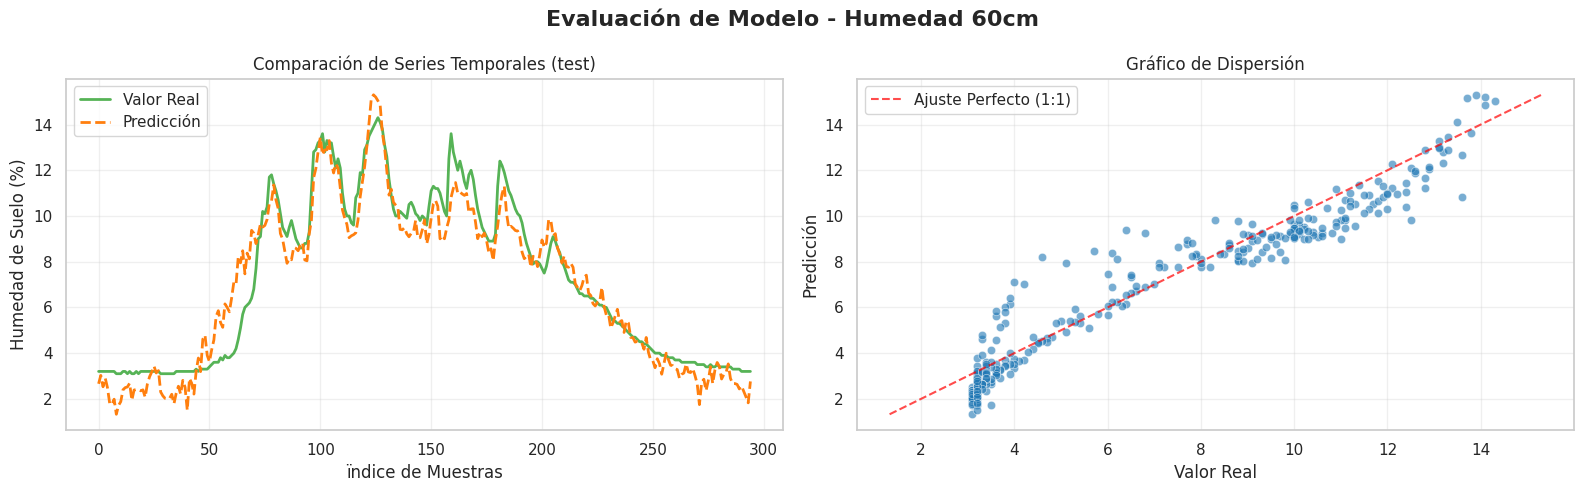

=== Humedad 100cm ===
R² Score (Precisión): 0.7940
Error Medio Absoluto (MAE): 0.2811
Raíz del Error Cuadrático Medio (RMSE): 0.4109
----------------------------------------


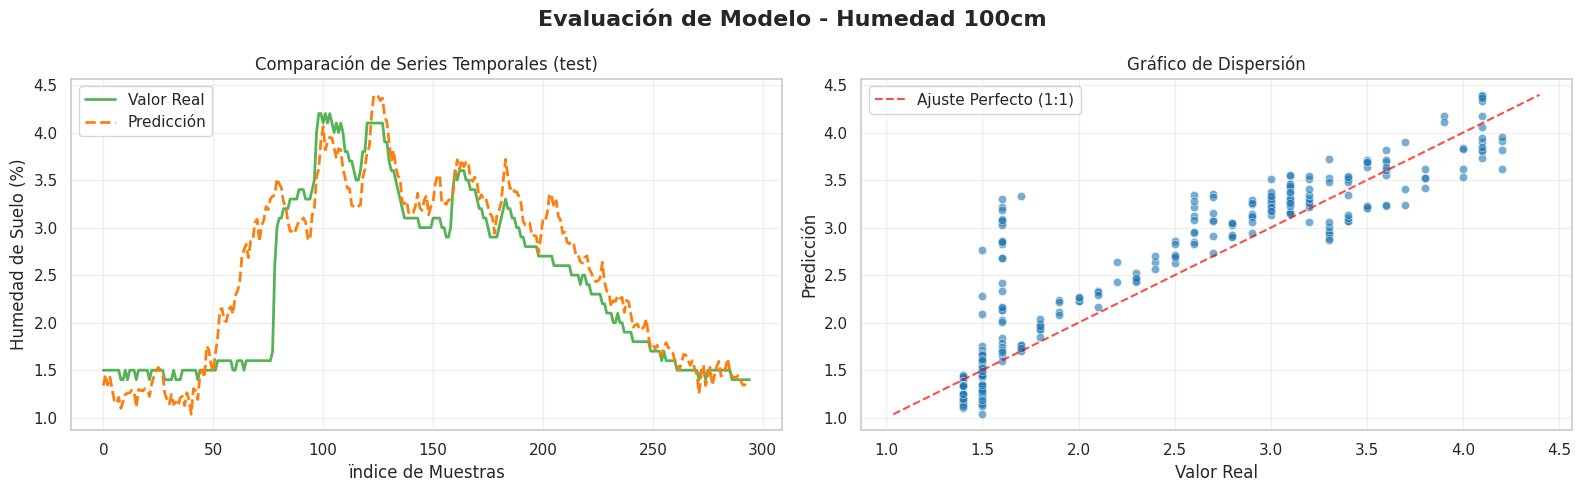

In [ ]:

reg_60 = LinearRegression(n_jobs=-1)
reg_100 = LinearRegression(n_jobs=-1)

modelos, resultados_ln = ejecutar_pipeline_escalonado(df_Estacion1, reg_60, reg_100)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_ln.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo SVR

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.8204
Error Medio Absoluto (MAE): 1.0463
Raíz del Error Cuadrático Medio (RMSE): 1.5086
----------------------------------------


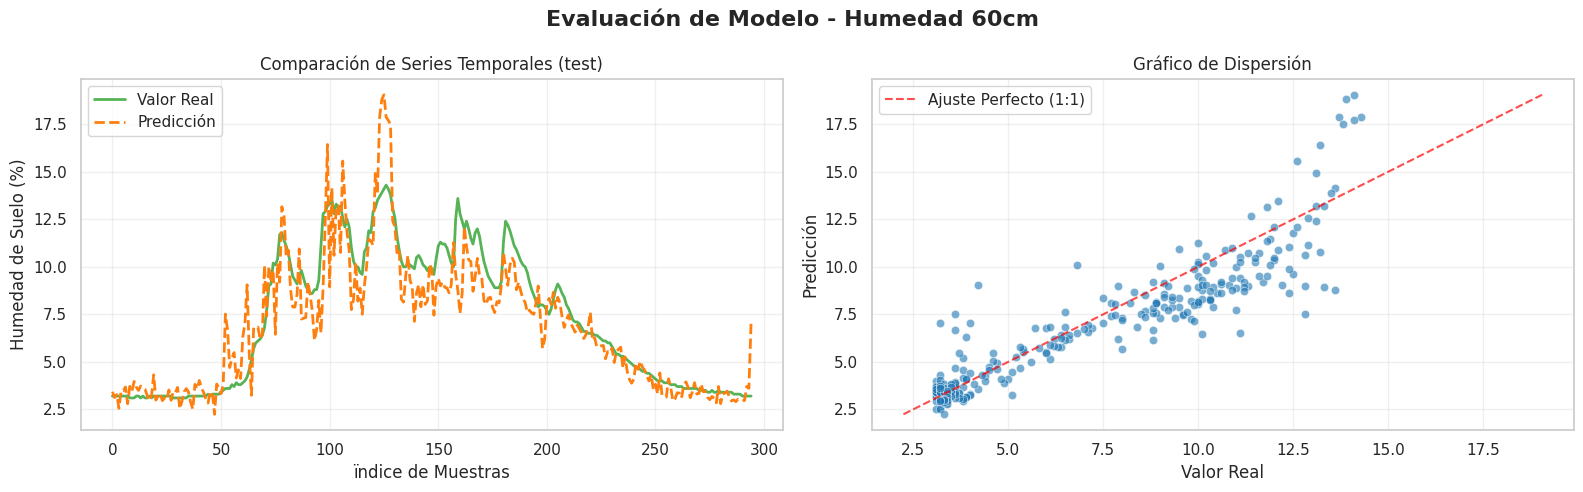

=== Humedad 100cm ===
R² Score (Precisión): 0.6622
Error Medio Absoluto (MAE): 0.3716
Raíz del Error Cuadrático Medio (RMSE): 0.5263
----------------------------------------


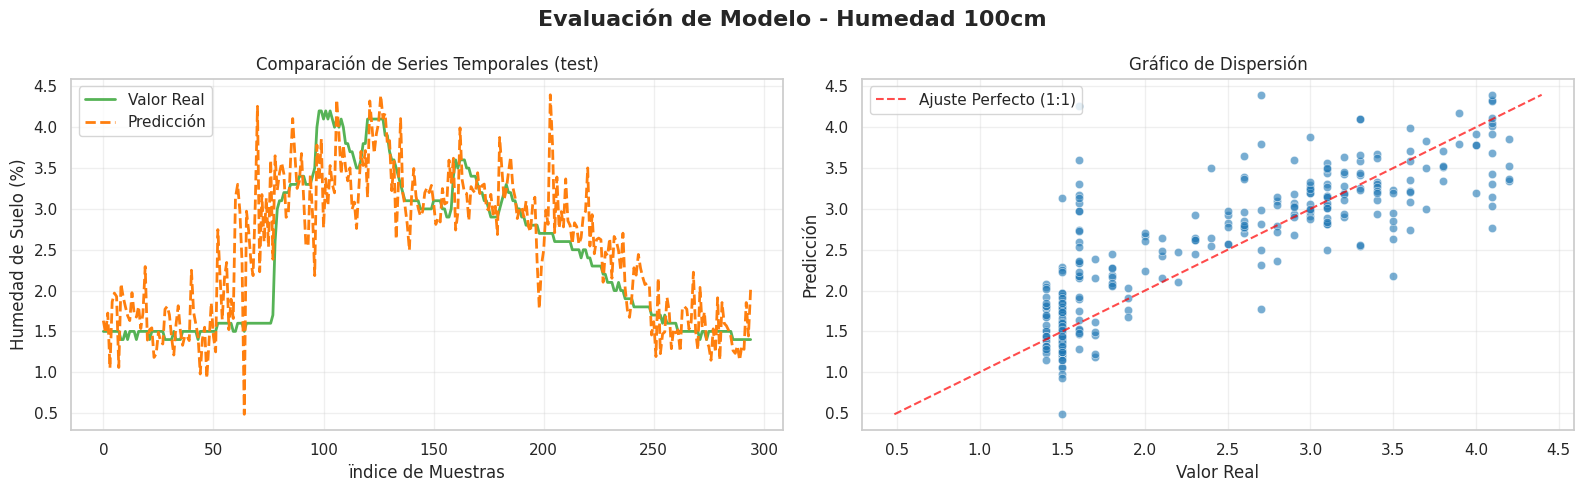

In [ ]:
reg_60 = modelo_SVR()
reg_100 = modelo_SVR()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_svr = ejecutar_pipeline_escalonado(df_Estacion1, reg_60, reg_100)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_svr.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo Random Forest

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.8984
Error Medio Absoluto (MAE): 0.7886
Raíz del Error Cuadrático Medio (RMSE): 1.1348
----------------------------------------


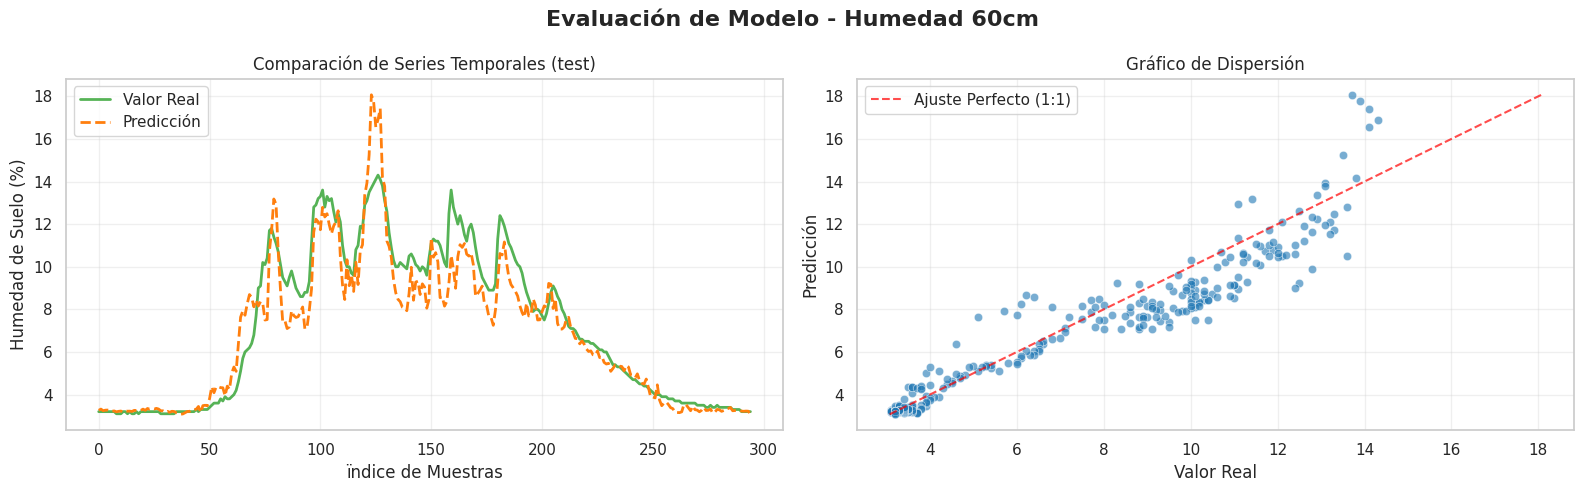

=== Humedad 100cm ===
R² Score (Precisión): 0.7989
Error Medio Absoluto (MAE): 0.2809
Raíz del Error Cuadrático Medio (RMSE): 0.4061
----------------------------------------


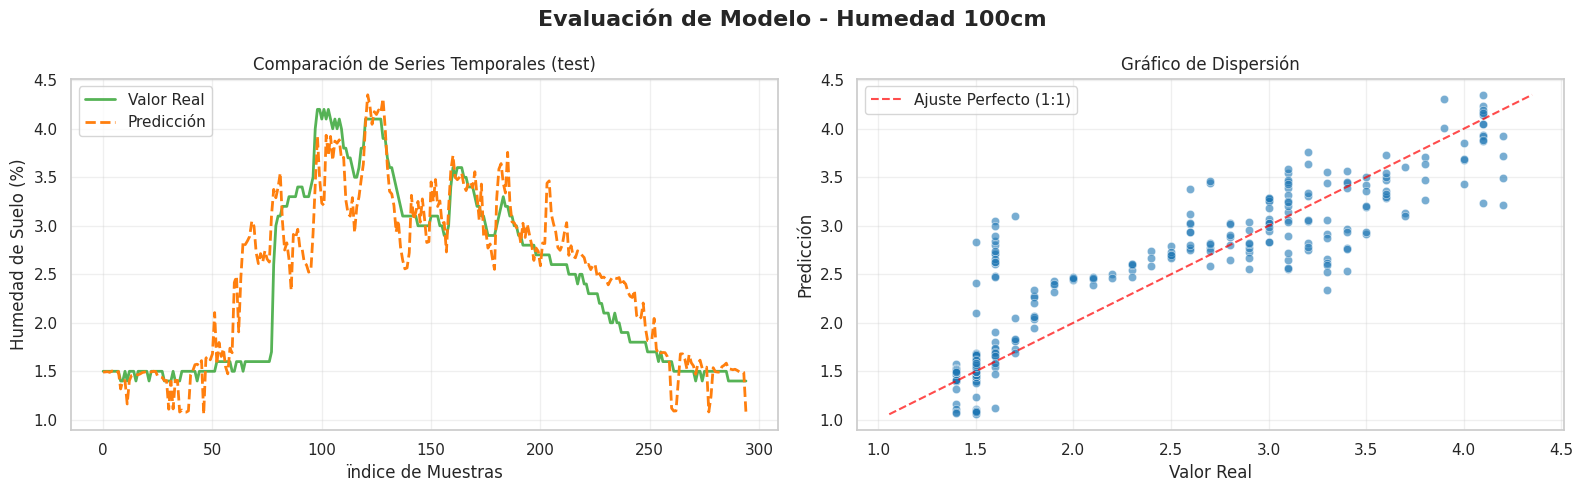

In [ ]:
reg_60 = modelo_RandomForest()
reg_100 = modelo_RandomForest()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_rf = ejecutar_pipeline_escalonado(df_Estacion1, reg_60, reg_100)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_rf.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo XGboost

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.8880
Error Medio Absoluto (MAE): 0.8091
Raíz del Error Cuadrático Medio (RMSE): 1.1913
----------------------------------------


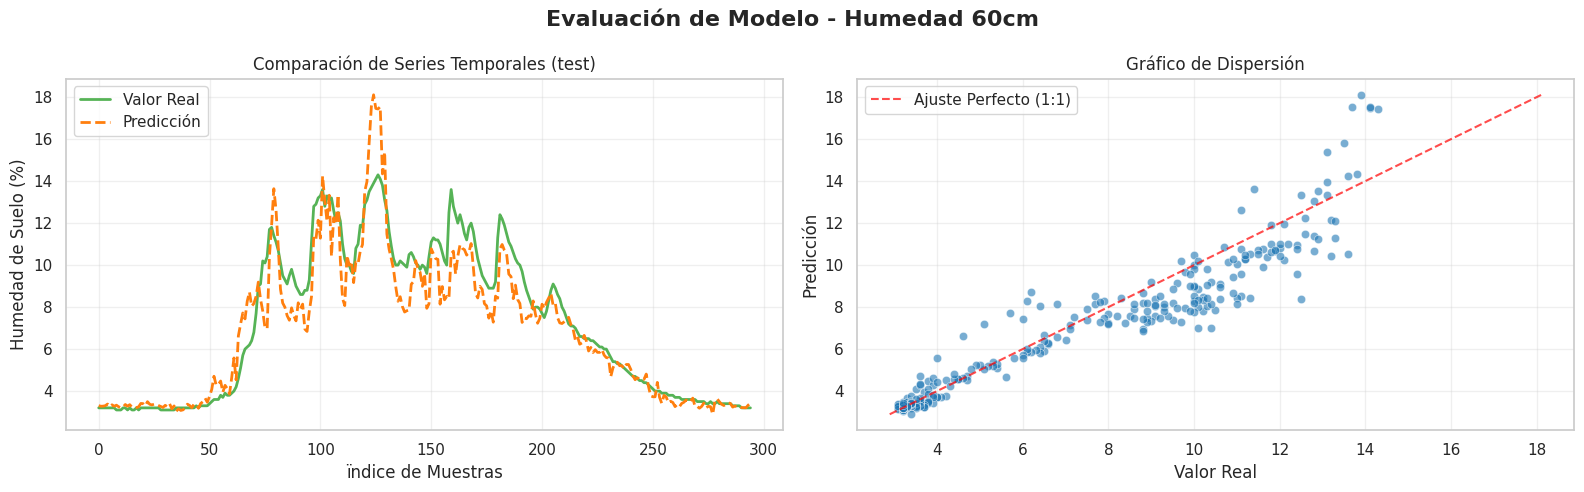

=== Humedad 100cm ===
R² Score (Precisión): 0.7953
Error Medio Absoluto (MAE): 0.2803
Raíz del Error Cuadrático Medio (RMSE): 0.4097
----------------------------------------


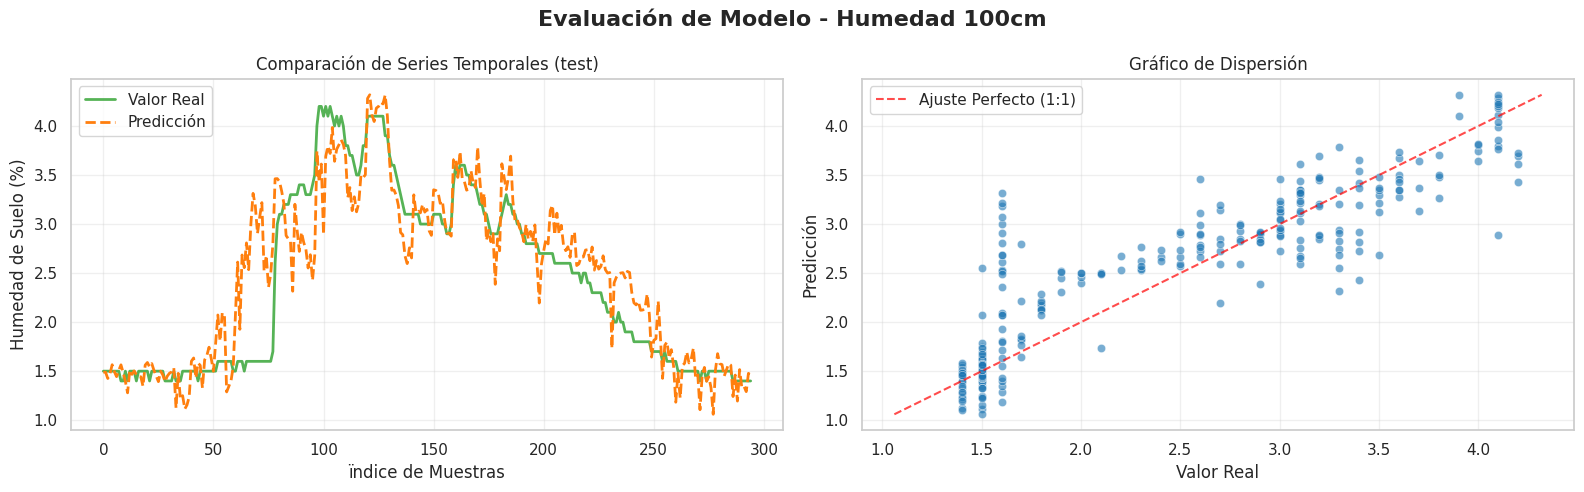

In [ ]:
reg_60 = modelo_XGBoost()
reg_100 = modelo_XGBoost()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_xgb = ejecutar_pipeline_escalonado(df_Estacion1, reg_60, reg_100)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_xgb.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def comparar_metricas_totales(diccionario_experimentos):
    """
    Recibe un diccionario con los resultados de múltiples modelos,
    calcula sus métricas clave, muestra tablas comparativas ordenadas
    y genera un gráfico de barras del R² para ambas profundidades (60cm y 100cm).
    """
    datos_60cm = []
    datos_100cm = []

    # Extraer métricas de forma dinámica para cada modelo del diccionario
    for nombre_modelo, resultados in diccionario_experimentos.items():
        # --- Métricas para la capa de 60cm ---
        if '60cm' in resultados:
            y_true_60 = resultados['60cm']['y_true']
            y_pred_60 = resultados['60cm']['y_pred']
            datos_60cm.append({
                'Modelo': nombre_modelo,
                'R2': r2_score(y_true_60, y_pred_60),
                'RMSE': np.sqrt(mean_squared_error(y_true_60, y_pred_60)),
                'MAE': mean_absolute_error(y_true_60, y_pred_60)
            })

        # --- Métricas para la capa de 100cm ---
        if '100cm' in resultados:
            y_true_100 = resultados['100cm']['y_true']
            y_pred_100 = resultados['100cm']['y_pred']
            datos_100cm.append({
                'Modelo': nombre_modelo,
                'R2': r2_score(y_true_100, y_pred_100),
                'RMSE': np.sqrt(mean_squared_error(y_true_100, y_pred_100)),
                'MAE': mean_absolute_error(y_true_100, y_pred_100)
            })

    # Convertir las listas en DataFrames de Pandas
    df_60 = pd.DataFrame(datos_60cm).set_index('Modelo') if datos_60cm else pd.DataFrame()
    df_100 = pd.DataFrame(datos_100cm).set_index('Modelo') if datos_100cm else pd.DataFrame()

    # --- IMPRIMIR TABLAS ORDENADAS EN CONSOLA ---
    if not df_60.empty:
        print("\n" + "="*60)
        print(" RANKING DE MODELOS - HUMEDAD 60 CM (Ordenado por R²)")
        print("="*60)
        print(df_60.sort_values(by='R2', ascending=False).round(4))

    if not df_100.empty:
        print("\n" + "="*60)
        print(" RANKING DE MODELOS - HUMEDAD 100 CM (Ordenado por R²)")
        print("="*60)
        print(df_100.sort_values(by='R2', ascending=False).round(4))

    # --- GENERAR GRÁFICO DE BARRAS COMPARATIVO ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    fig.suptitle('Comparativa del Coeficiente de Determinación ($R^2$) entre Modelos', fontsize=16, fontweight='bold')

    # Subplot 1: 60cm
    if not df_60.empty:
        df_60_sorted = df_60.reset_index().sort_values(by='R2', ascending=False)
        sns.barplot(x='R2', y='Modelo', data=df_60_sorted, ax=axes[0], palette='viridis', hue='Modelo', legend=False)
        axes[0].set_title('Humedad a 60 cm')
        axes[0].set_xlabel('$R^2$')
        axes[0].set_ylabel('Modelo')

    # Subplot 2: 100cm
    if not df_100.empty:
        df_100_sorted = df_100.reset_index().sort_values(by='R2', ascending=False)
        sns.barplot(x='R2', y='Modelo', data=df_100_sorted, ax=axes[1], palette='plasma', hue='Modelo', legend=False)
        axes[1].set_title('Humedad a 100 cm')
        axes[1].set_xlabel('$R^2$')
        axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    return df_60, df_100


 RANKING DE MODELOS - HUMEDAD 60 CM (Ordenado por R²)
                     R2    RMSE     MAE
Modelo                                 
Lineal Múltiple  0.9205  1.0036  0.7749
Random Forest    0.8984  1.1348  0.7886
XGBoost          0.8880  1.1913  0.8091
SVR              0.8204  1.5086  1.0463

 RANKING DE MODELOS - HUMEDAD 100 CM (Ordenado por R²)
                     R2    RMSE     MAE
Modelo                                 
Random Forest    0.7989  0.4061  0.2809
XGBoost          0.7953  0.4097  0.2803
Lineal Múltiple  0.7940  0.4109  0.2811
SVR              0.6622  0.5263  0.3716


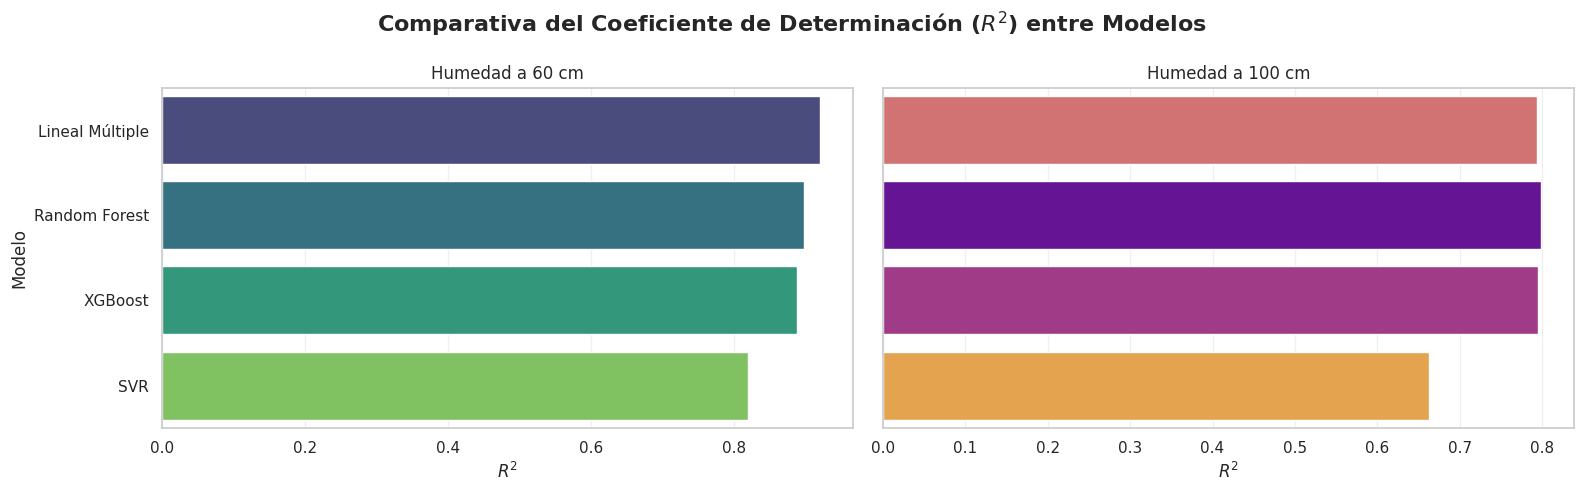

In [ ]:
experimentos_estacion3 = {
    'Lineal Múltiple': resultados_ln, # Usa la variable donde guardaste la regresión lineal
    'SVR': resultados_svr,
    'Random Forest': resultados_rf,
    'XGBoost': resultados_xgb
}

# Llamamos a la función
tablas_60, tablas_100 = comparar_metricas_totales(experimentos_estacion3)

#### **Predicción para la Estación 2**

In [ ]:
df_Estacion2 = df22.copy()
df_Estacion2

,Precipitación,Temp_Max,Temp_Min,Temp_Prom,Evapotranspiración,Humedad Relativa,HUMEDAD SUELO-20,HUMEDAD SUELO-60,HUMEDAD SUELO-100
fecha,,,,,,,,,
2019-08-15,0.0,20.6,0.5,7.917361,-3.880511e-08,51.167792,1.2,2.1,6.0
2019-08-16,0.0,20.7,-0.5,8.312500,9.701277e-09,42.618698,1.2,2.1,6.0
2019-08-17,0.0,22.4,0.4,8.788542,-3.880511e-08,42.100011,1.2,2.1,6.0
2019-08-18,0.0,22.4,1.3,9.153819,0.000000e+00,52.929224,1.2,2.1,5.9
2019-08-19,0.0,21.9,1.9,9.052083,0.000000e+00,59.205051,1.1,2.0,5.9
...,...,...,...,...,...,...,...,...,...
2023-08-27,0.0,20.6,1.1,8.420833,0.000000e+00,61.788887,3.6,2.5,5.0
2023-08-28,0.0,21.1,1.7,8.608333,0.000000e+00,63.633372,3.6,2.5,5.0
2023-08-29,0.0,24.7,1.6,9.387500,-3.880511e-08,67.228068,3.6,2.5,5.0


##### Modelo Regresión Lineal Multiple

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.6545
Error Medio Absoluto (MAE): 0.6876
Raíz del Error Cuadrático Medio (RMSE): 0.9482
----------------------------------------


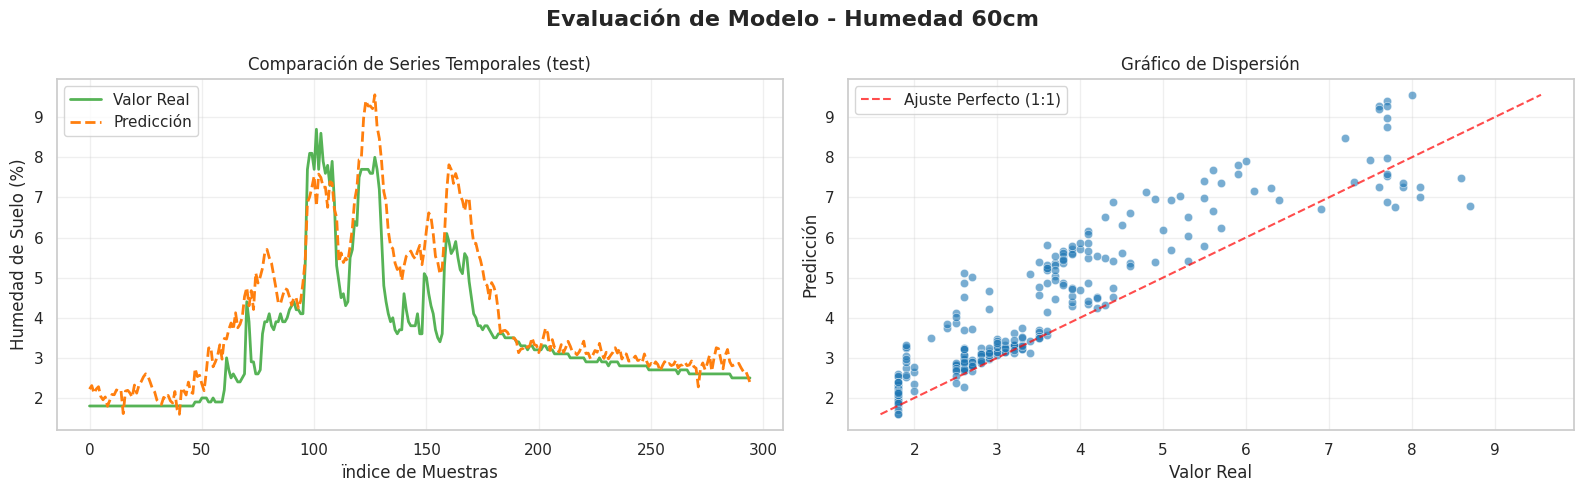

=== Humedad 100cm ===
R² Score (Precisión): 0.7735
Error Medio Absoluto (MAE): 1.5198
Raíz del Error Cuadrático Medio (RMSE): 1.9246
----------------------------------------


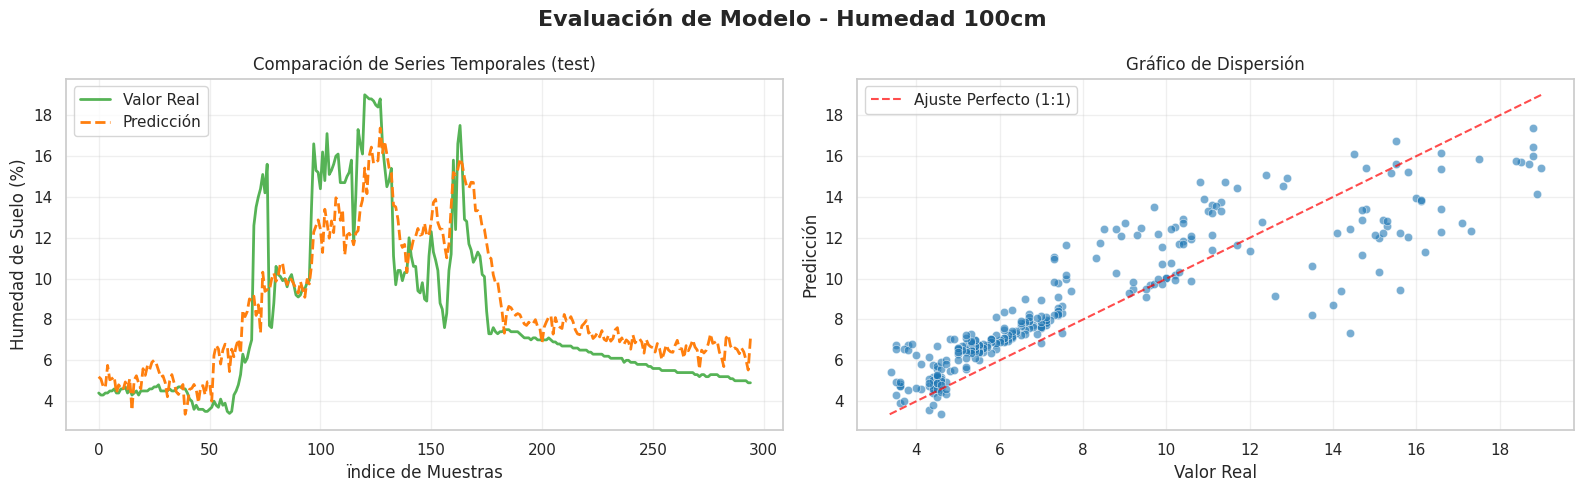

In [ ]:
reg_60_Est2 = LinearRegression(n_jobs=-1)
reg_100_Est2 = LinearRegression(n_jobs=-1)

modelos, resultados_ln = ejecutar_pipeline_escalonado(df_Estacion2, reg_60_Est2, reg_100_Est2)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_ln.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo SVR

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.0400
Error Medio Absoluto (MAE): 1.0941
Raíz del Error Cuadrático Medio (RMSE): 1.5807
----------------------------------------


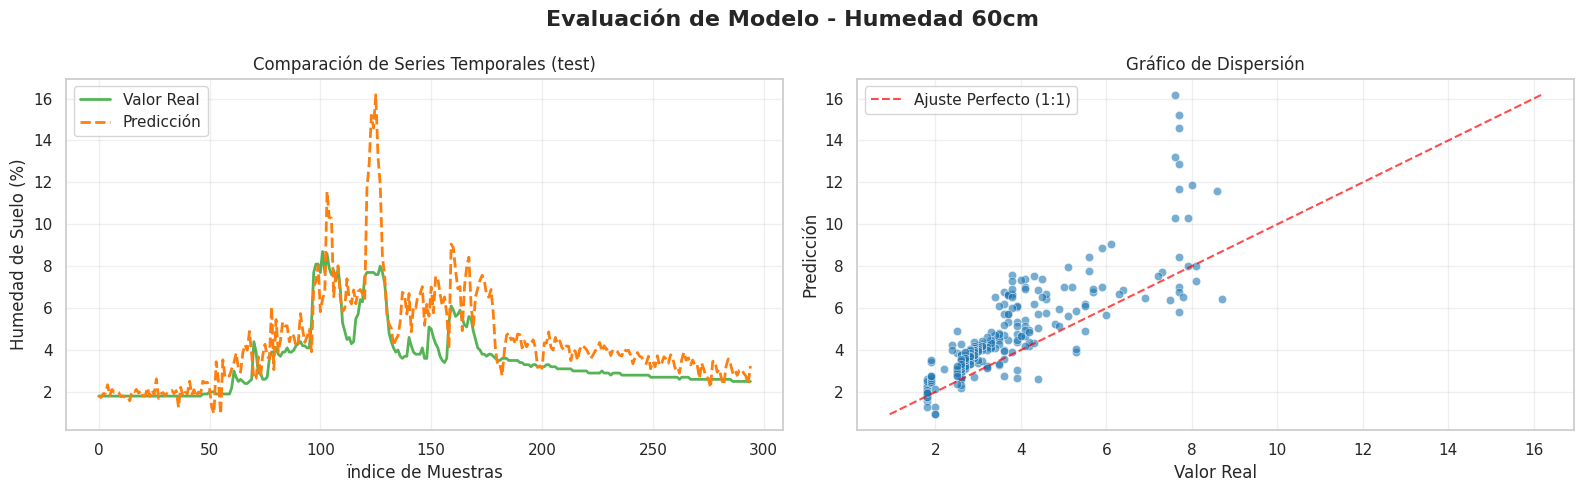

=== Humedad 100cm ===
R² Score (Precisión): 0.1619
Error Medio Absoluto (MAE): 2.8626
Raíz del Error Cuadrático Medio (RMSE): 3.7016
----------------------------------------


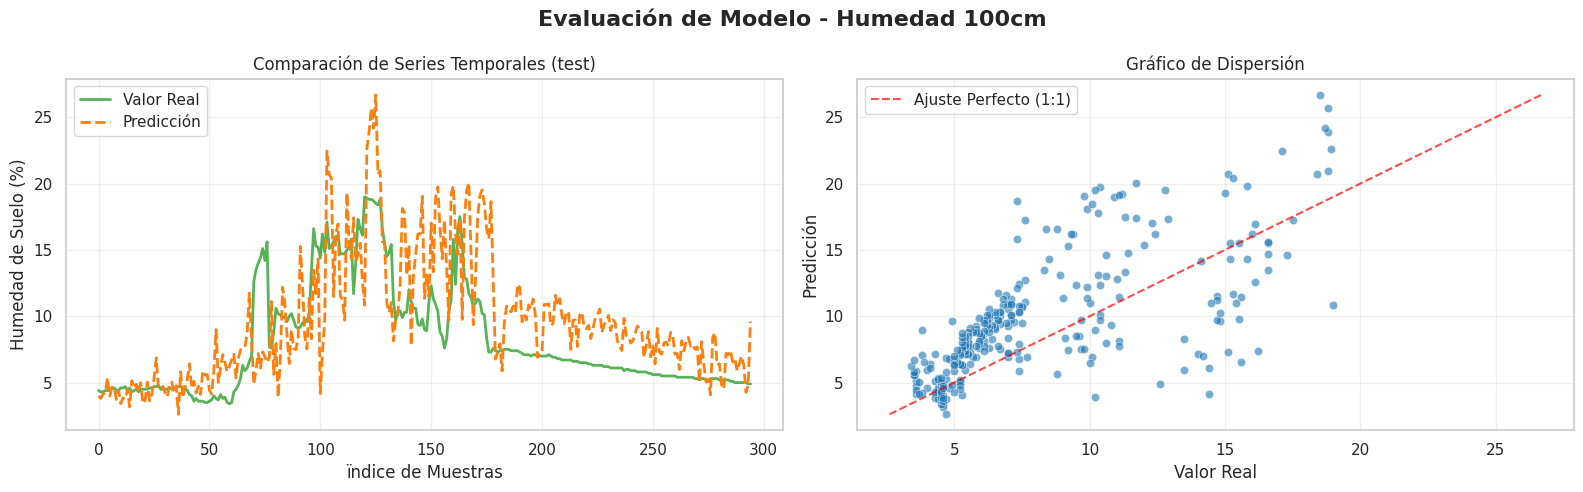

In [ ]:
reg_60_Est2 = modelo_SVR()
reg_100_Est2 = modelo_SVR()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_svr = ejecutar_pipeline_escalonado(df_Estacion2, reg_60_Est2, reg_100_Est2)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_svr.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo Random Forest

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.5376
Error Medio Absoluto (MAE): 0.6786
Raíz del Error Cuadrático Medio (RMSE): 1.0970
----------------------------------------


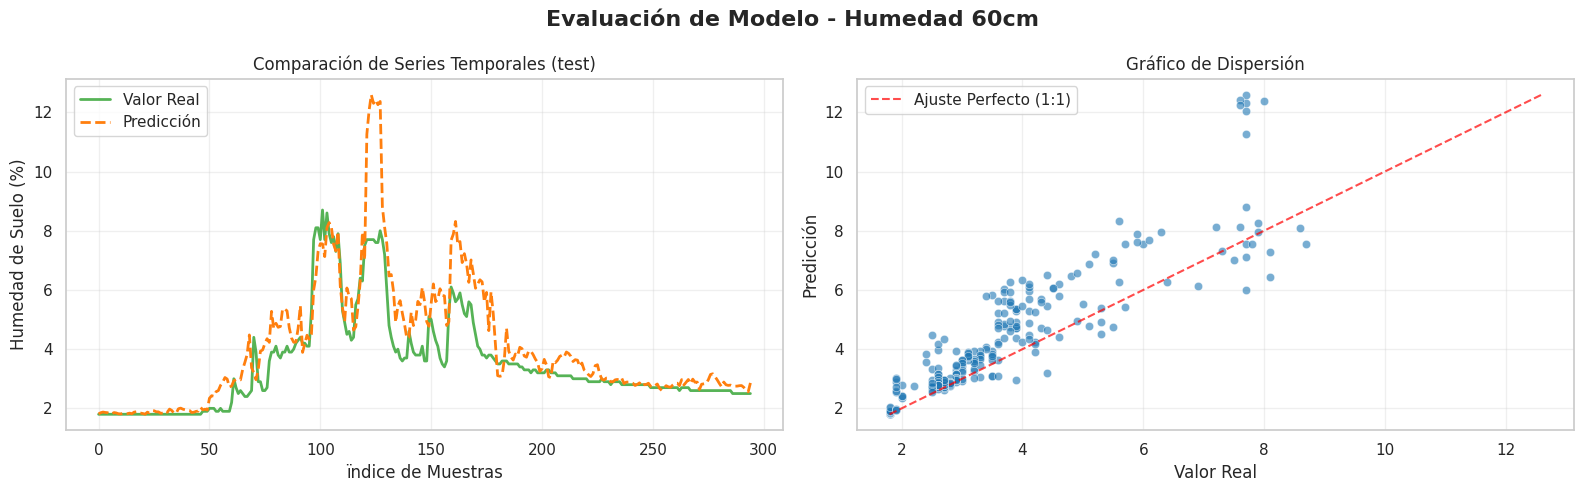

=== Humedad 100cm ===
R² Score (Precisión): 0.5678
Error Medio Absoluto (MAE): 1.7376
Raíz del Error Cuadrático Medio (RMSE): 2.6583
----------------------------------------


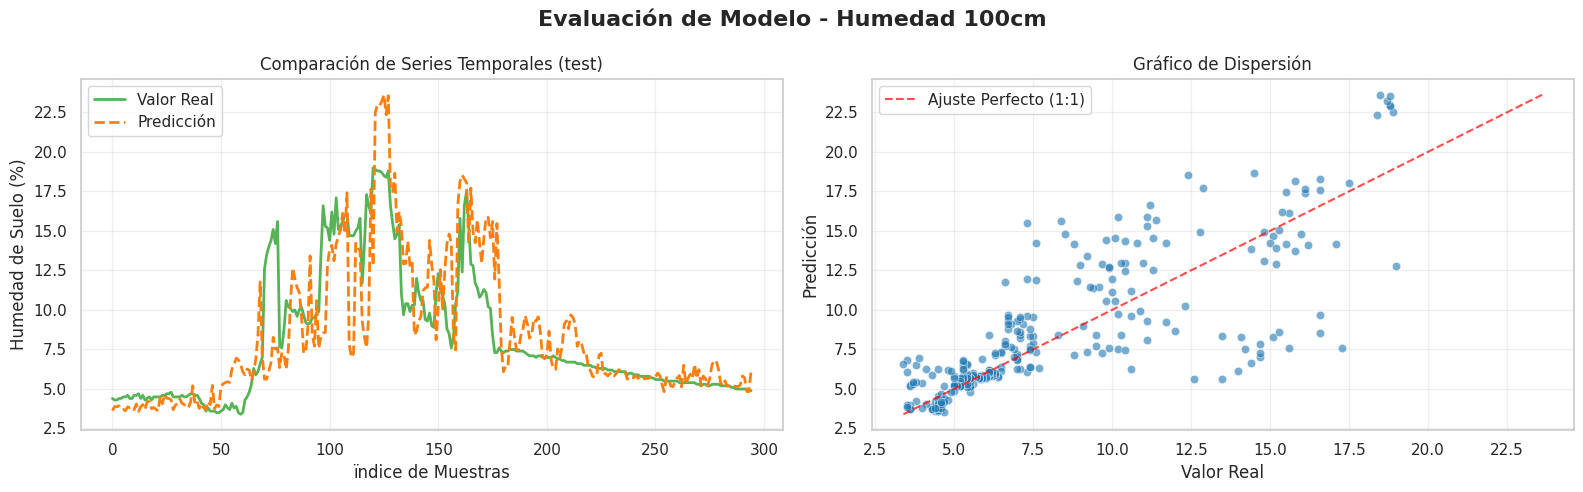

In [ ]:
reg_60 = modelo_RandomForest()
reg_100 = modelo_RandomForest()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_rf = ejecutar_pipeline_escalonado(df_Estacion2, reg_60, reg_100)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_rf.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo XGboost

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.4682
Error Medio Absoluto (MAE): 0.7882
Raíz del Error Cuadrático Medio (RMSE): 1.1764
----------------------------------------


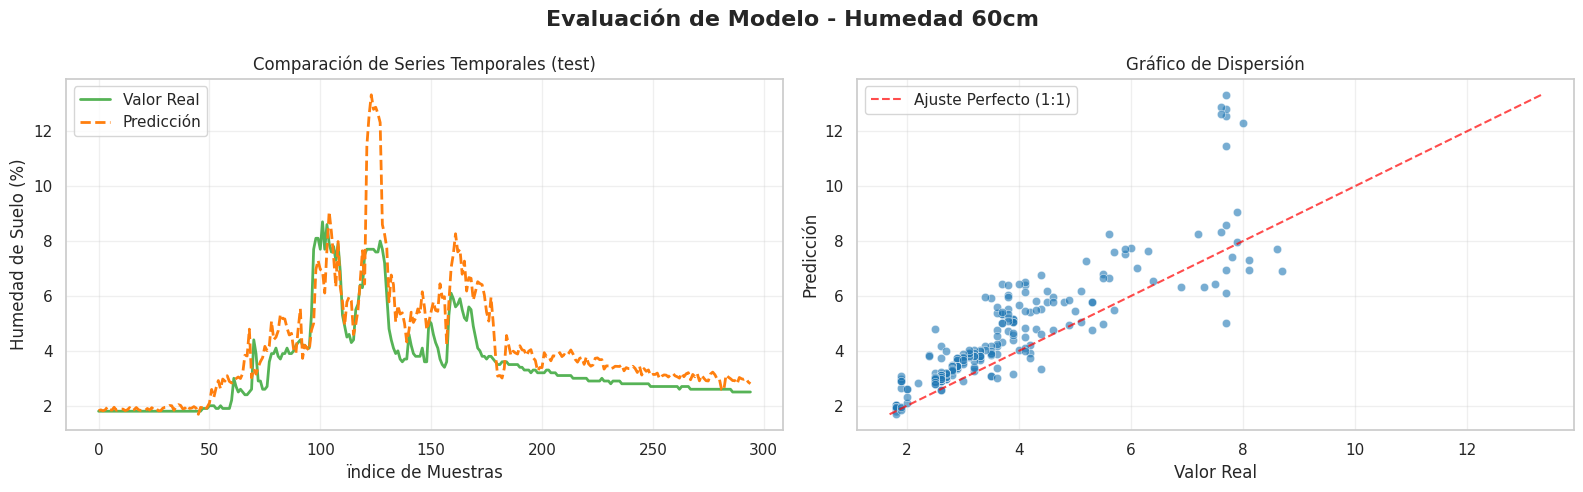

=== Humedad 100cm ===
R² Score (Precisión): 0.4806
Error Medio Absoluto (MAE): 2.1494
Raíz del Error Cuadrático Medio (RMSE): 2.9140
----------------------------------------


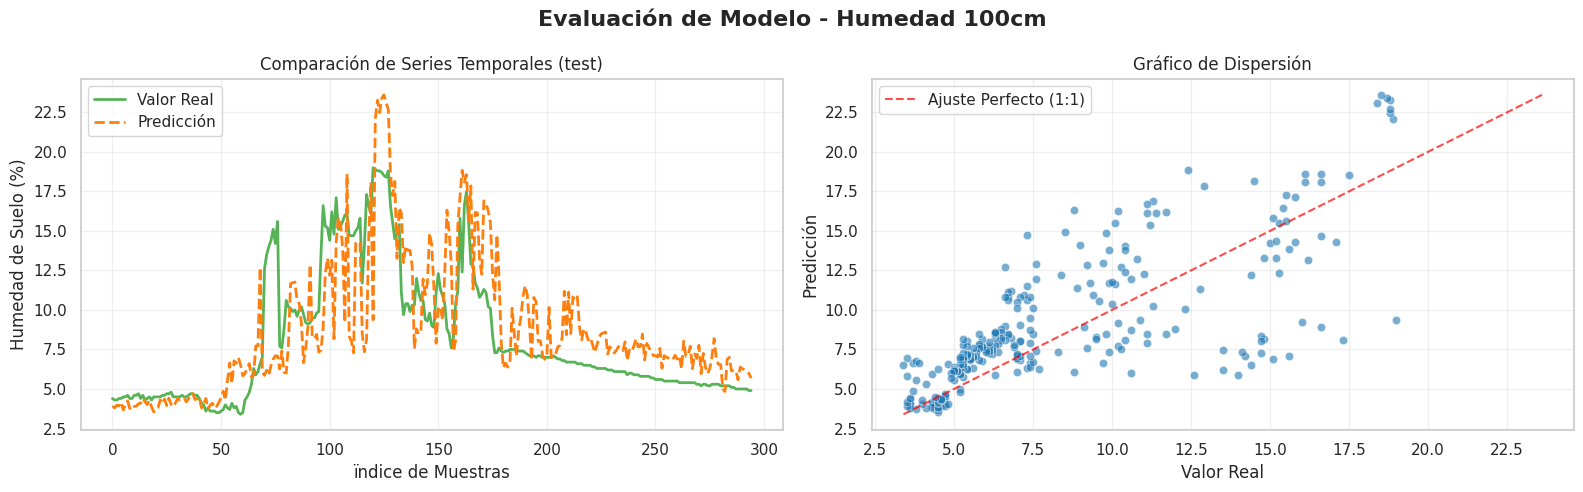

In [ ]:
reg_60 = modelo_XGBoost()
reg_100 = modelo_XGBoost()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_xgb = ejecutar_pipeline_escalonado(df_Estacion2, reg_60, reg_100)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_xgb.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])


 RANKING DE MODELOS - HUMEDAD 60 CM (Ordenado por R²)
                     R2    RMSE     MAE
Modelo                                 
Lineal Múltiple  0.6545  0.9482  0.6876
Random Forest    0.5376  1.0970  0.6786
XGBoost          0.4682  1.1764  0.7882
SVR              0.0400  1.5807  1.0941

 RANKING DE MODELOS - HUMEDAD 100 CM (Ordenado por R²)
                     R2    RMSE     MAE
Modelo                                 
Lineal Múltiple  0.7735  1.9246  1.5198
Random Forest    0.5678  2.6583  1.7376
XGBoost          0.4806  2.9140  2.1494
SVR              0.1619  3.7016  2.8626


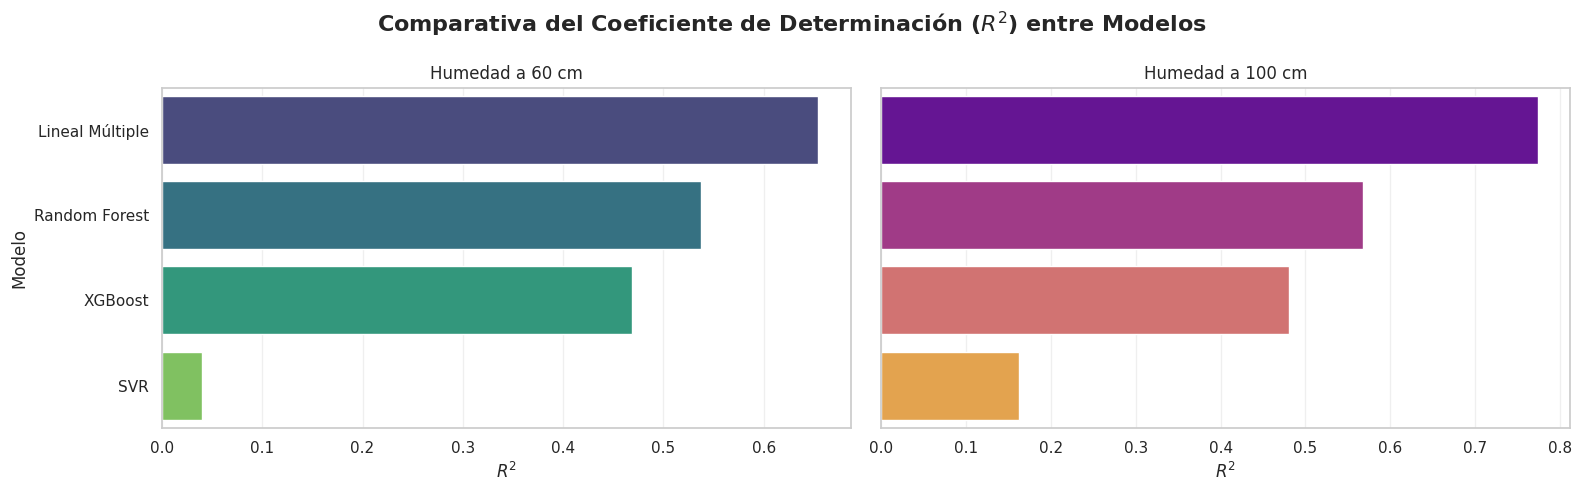

In [ ]:
experimentos_estacion3 = {
    'Lineal Múltiple': resultados_ln, # Usa la variable donde guardaste la regresión lineal
    'SVR': resultados_svr,
    'Random Forest': resultados_rf,
    'XGBoost': resultados_xgb
}

# Llamamos a la función
tablas_60, tablas_100 = comparar_metricas_totales(experimentos_estacion3)

#### **Predicción para la Estación 3**

In [ ]:
df_Estacion3 = df33.copy()
df_Estacion3

,Precipitación,Temp_Max,Temp_Min,Temp_Prom,Evapotranspiración,Humedad Relativa,HUMEDAD SUELO-20,HUMEDAD SUELO-60,HUMEDAD SUELO-100
fecha,,,,,,,,,
2019-08-15,0.0,20.6,0.5,7.92,-0.0,51.17,13.5,10.4,25.0
2019-08-16,0.0,20.7,-0.5,8.31,0.0,42.62,13.2,10.3,25.0
2019-08-17,0.0,22.4,0.4,8.79,-0.0,42.10,12.9,10.2,24.9
2019-08-18,0.0,22.4,1.3,9.15,0.0,52.93,12.5,10.1,24.8
2019-08-19,0.0,21.9,1.9,9.05,0.0,59.21,12.2,10.0,24.7
...,...,...,...,...,...,...,...,...,...
2022-03-31,3.2,11.9,4.0,7.00,0.0,93.78,32.7,19.1,32.1
2022-04-01,9.9,12.7,4.5,6.92,-0.0,91.75,32.9,18.8,31.9
2022-04-02,15.8,13.6,3.5,6.23,0.0,91.04,33.9,19.8,32.8


##### Modelo de Regresión Lineal Multiple

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.5402
Error Medio Absoluto (MAE): 1.6192
Raíz del Error Cuadrático Medio (RMSE): 1.9839
----------------------------------------


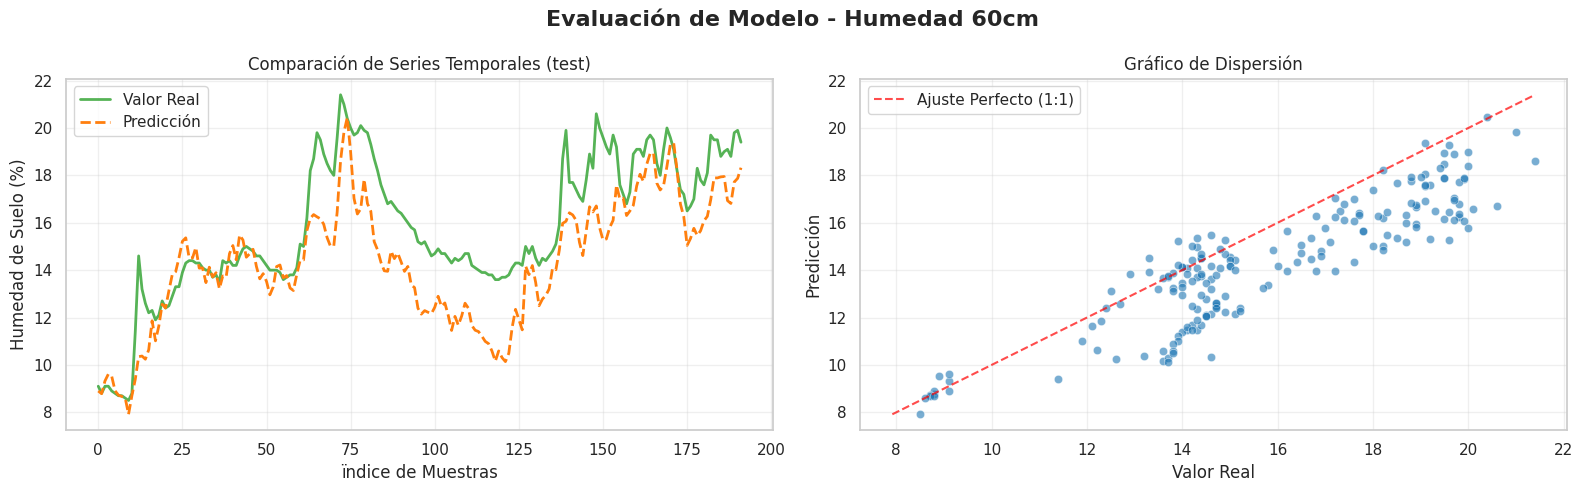

=== Humedad 100cm ===
R² Score (Precisión): 0.4456
Error Medio Absoluto (MAE): 2.0514
Raíz del Error Cuadrático Medio (RMSE): 2.2867
----------------------------------------


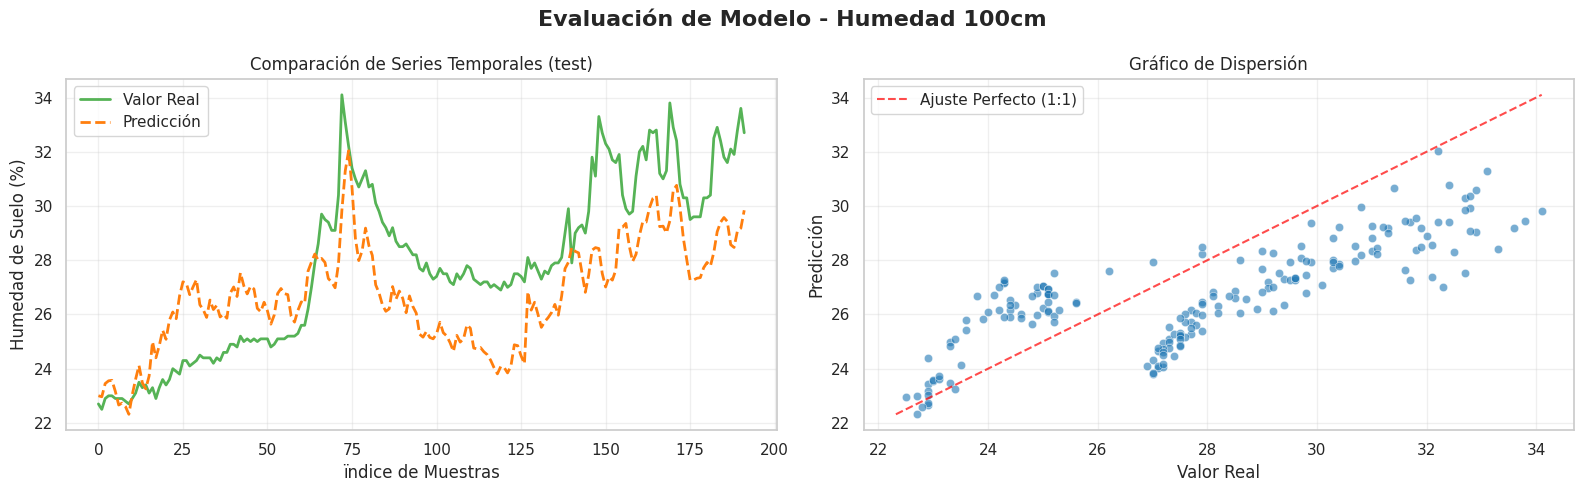

In [ ]:
reg_60_Est3 = LinearRegression(n_jobs=-1)
reg_100_Est3 = LinearRegression(n_jobs=-1)

modelos, resultados_ln = ejecutar_pipeline_escalonado(df_Estacion3, reg_60_Est3, reg_100_Est3)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_ln.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo SVR

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.3315
Error Medio Absoluto (MAE): 1.9179
Raíz del Error Cuadrático Medio (RMSE): 2.3922
----------------------------------------


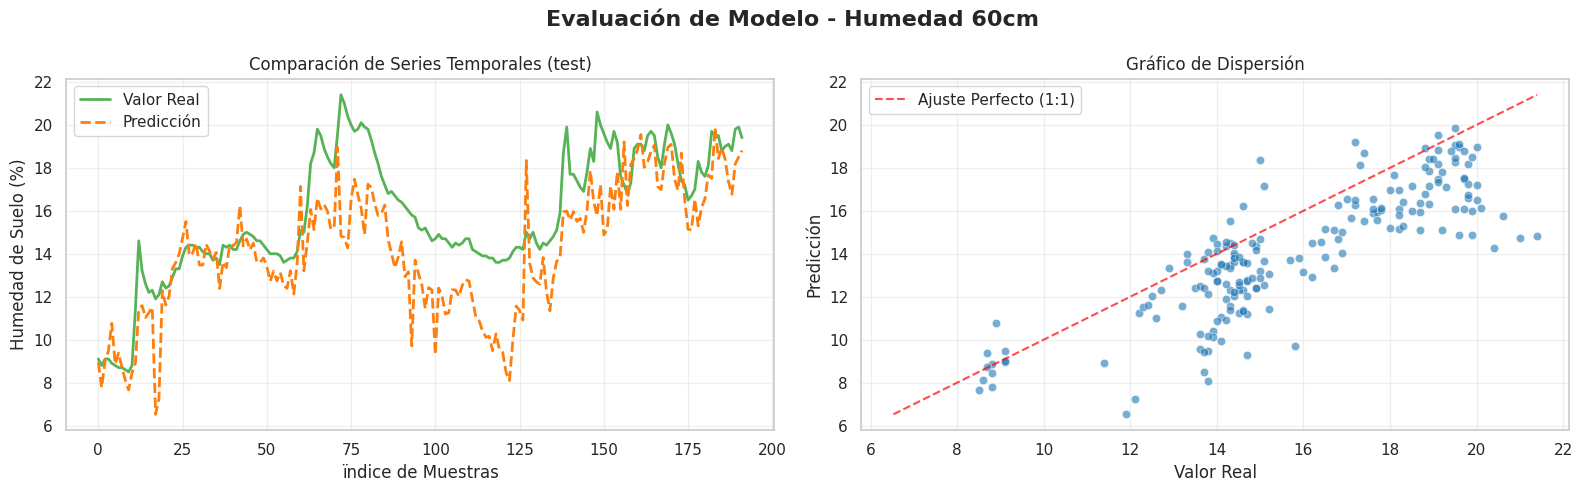

=== Humedad 100cm ===
R² Score (Precisión): 0.3102
Error Medio Absoluto (MAE): 2.1798
Raíz del Error Cuadrático Medio (RMSE): 2.5508
----------------------------------------


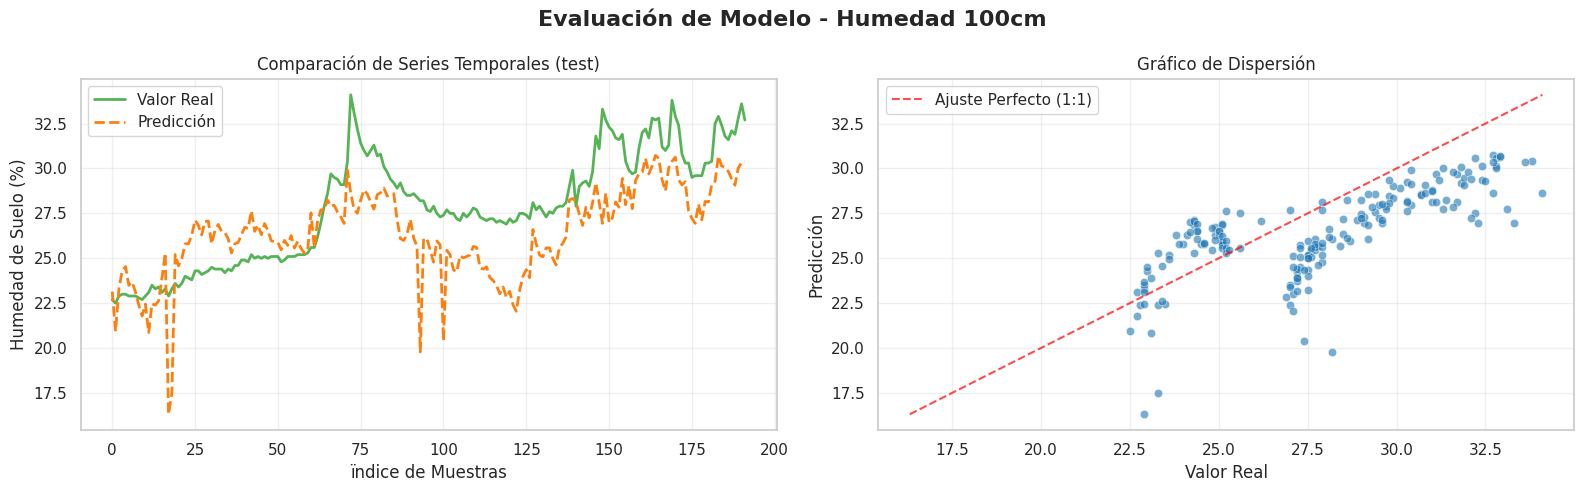

In [ ]:
reg_60_Est3 = modelo_SVR()
reg_100_Est3 = modelo_SVR()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_svr = ejecutar_pipeline_escalonado(df_Estacion3, reg_60_Est3, reg_100_Est3)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_svr.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo Random Forest

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.4852
Error Medio Absoluto (MAE): 1.7642
Raíz del Error Cuadrático Medio (RMSE): 2.0993
----------------------------------------


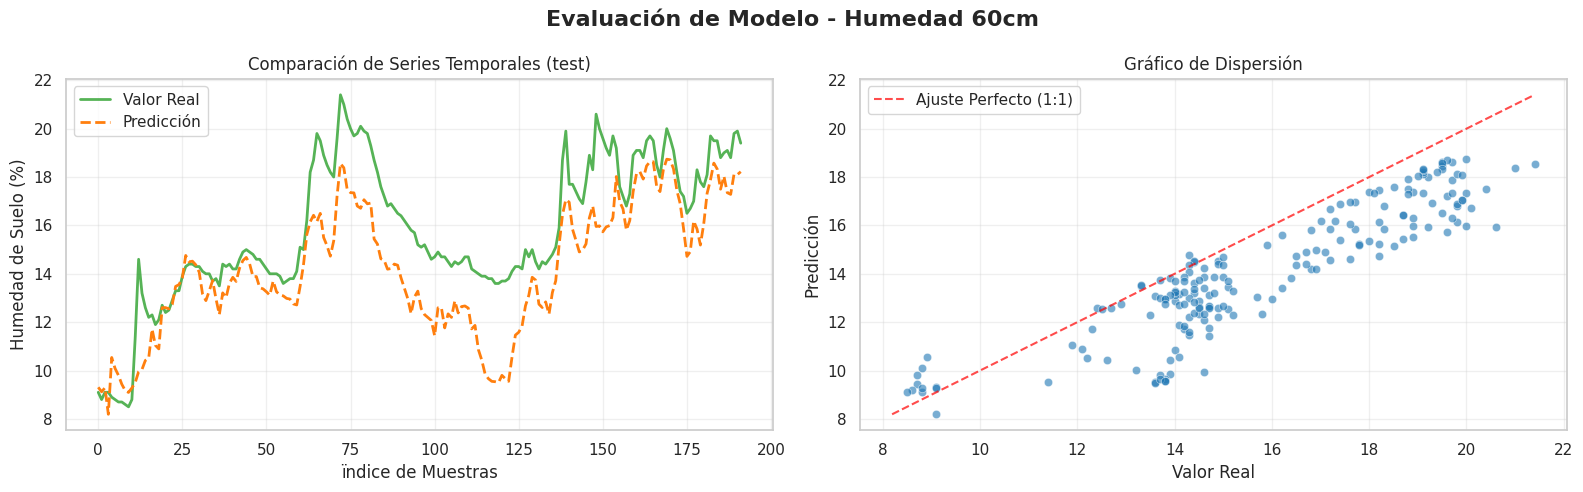

=== Humedad 100cm ===
R² Score (Precisión): 0.4218
Error Medio Absoluto (MAE): 2.0834
Raíz del Error Cuadrático Medio (RMSE): 2.3354
----------------------------------------


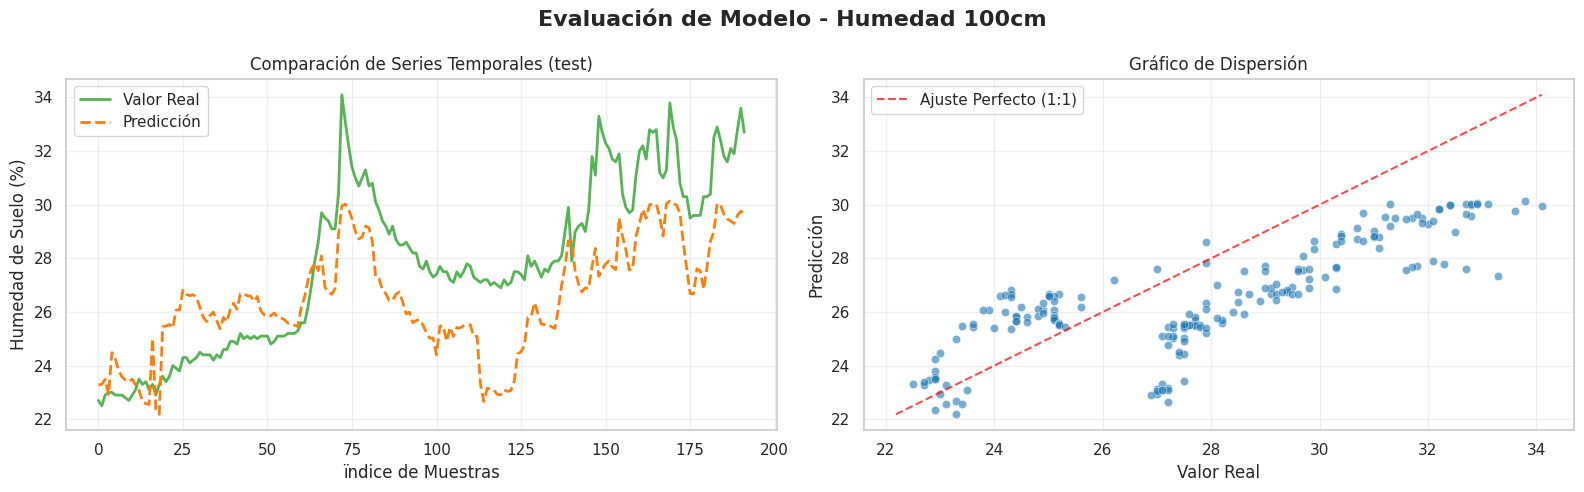

In [ ]:
reg_60_Est3 = modelo_RandomForest()
reg_100_Est3 = modelo_RandomForest()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_rf = ejecutar_pipeline_escalonado(df_Estacion3, reg_60_Est3, reg_100_Est3)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_rf.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])

##### Modelo XGboost

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
=== Humedad 60cm ===
R² Score (Precisión): 0.3315
Error Medio Absoluto (MAE): 1.9179
Raíz del Error Cuadrático Medio (RMSE): 2.3922
----------------------------------------


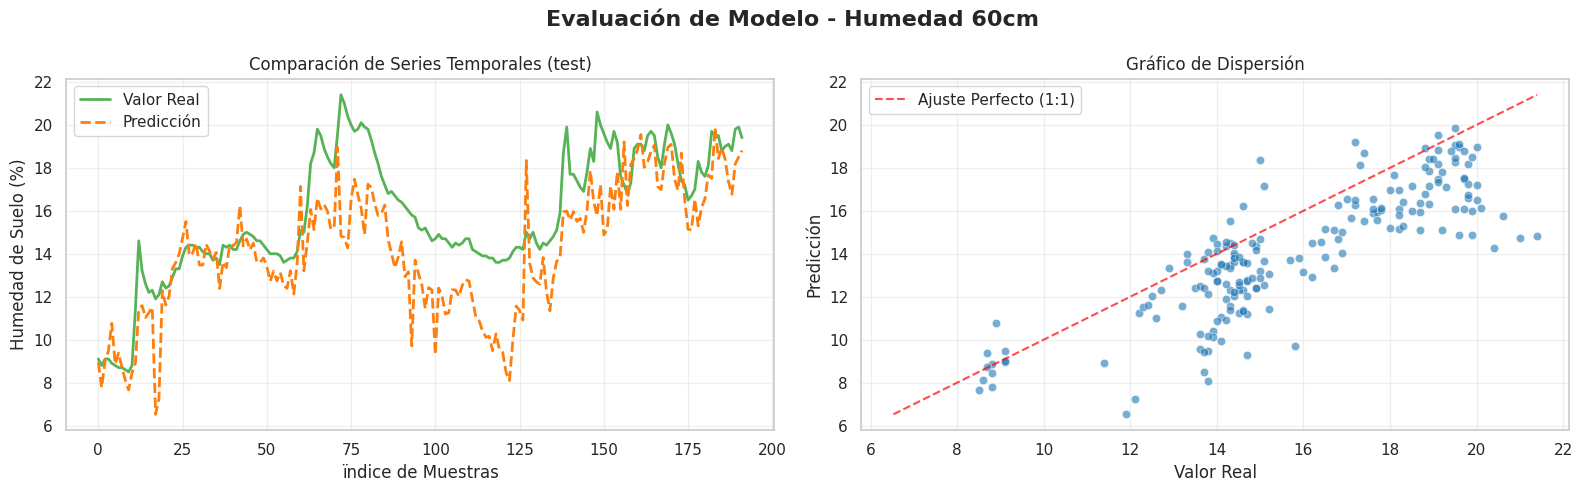

=== Humedad 100cm ===
R² Score (Precisión): 0.3118
Error Medio Absoluto (MAE): 2.2016
Raíz del Error Cuadrático Medio (RMSE): 2.5478
----------------------------------------


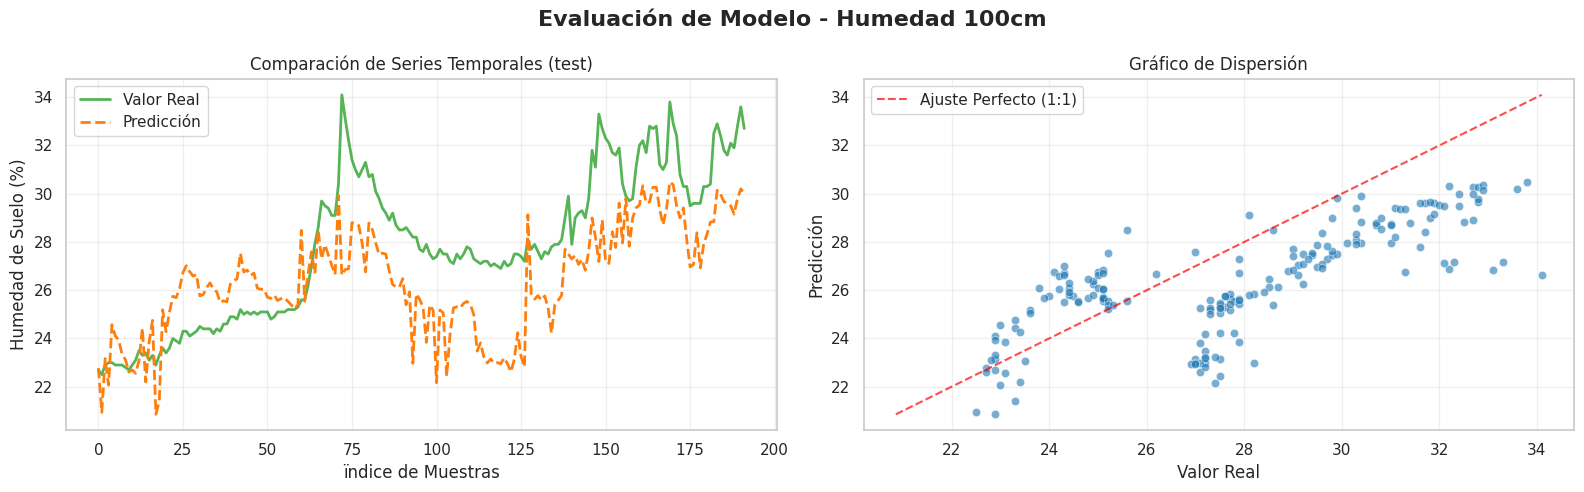

In [ ]:
reg_60_Est3 = modelo_XGBoost()
reg_100_Est3 = modelo_XGBoost()

# Ejecutamos el pipeline secuencial/escalonado
modelos, resultados_xgb = ejecutar_pipeline_escalonado(df_Estacion3, reg_60_Est2, reg_100_Est3)

# Evaluar/Graficar los resultados obtenidos
for capa, datos in resultados_xgb.items():
    metricas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])
    generar_graficas(f"Humedad {capa}", datos['y_true'], datos['y_pred'])


 RANKING DE MODELOS - HUMEDAD 60 CM (Ordenado por R²)
                     R2    RMSE     MAE
Modelo                                 
Lineal Múltiple  0.5402  1.9839  1.6192
Random Forest    0.4852  2.0993  1.7642
SVR              0.3315  2.3922  1.9179
XGBoost          0.3315  2.3922  1.9179

 RANKING DE MODELOS - HUMEDAD 100 CM (Ordenado por R²)
                     R2    RMSE     MAE
Modelo                                 
Lineal Múltiple  0.4456  2.2867  2.0514
Random Forest    0.4218  2.3354  2.0834
XGBoost          0.3118  2.5478  2.2016
SVR              0.3102  2.5508  2.1798


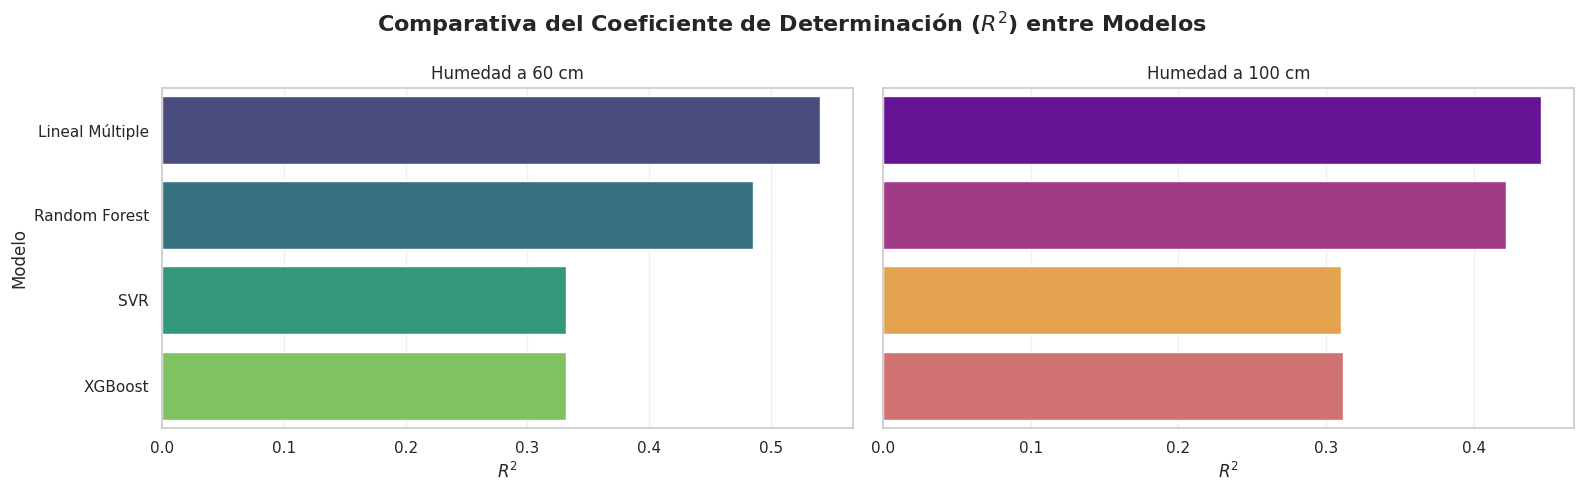

In [ ]:
experimentos_estacion3 = {
    'Lineal Múltiple': resultados_ln, # Usa la variable donde guardaste la regresión lineal
    'SVR': resultados_svr,
    'Random Forest': resultados_rf,
    'XGBoost': resultados_xgb
}

# Llamamos a la función
tablas_60, tablas_100 = comparar_metricas_totales(experimentos_estacion3)

In [ ]:
# ============================================================
# TABLA COMPARATIVA FINAL SIN MODIFICAR CELDAS ANTERIORES
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

# Lista donde se guardarán todos los resultados
resultados_tabla = []

# Función para calcular y guardar métricas
def guardar_metricas(nombre_estacion, nombre_modelo, capa, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    resultados_tabla.append({
        "Estación": nombre_estacion,
        "Modelo": nombre_modelo,
        "Profundidad predicha": capa,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

# Función para ejecutar un modelo y guardar resultados
def evaluar_modelo_para_tabla(nombre_estacion, df_estacion, nombre_modelo, modelo_60, modelo_100):
    modelos, resultados = ejecutar_pipeline_escalonado(
        df_estacion,
        modelo_60,
        modelo_100
    )

    for capa, datos in resultados.items():
        guardar_metricas(
            nombre_estacion=nombre_estacion,
            nombre_modelo=nombre_modelo,
            capa=capa,
            y_true=datos["y_true"],
            y_pred=datos["y_pred"]
        )

# ============================================================
# ESTACIÓN 1
# ============================================================

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-02",
    df_Estacion1,
    "Regresión Lineal",
    LinearRegression(n_jobs=-1),
    LinearRegression(n_jobs=-1)
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-02",
    df_Estacion1,
    "SVR",
    modelo_SVR(),
    modelo_SVR()
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-02",
    df_Estacion1,
    "Random Forest",
    modelo_RandomForest(),
    modelo_RandomForest()
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-02",
    df_Estacion1,
    "XGBoost",
    modelo_XGBoost(),
    modelo_XGBoost()
)

# ============================================================
# ESTACIÓN 2
# ============================================================

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-03",
    df_Estacion2,
    "Regresión Lineal",
    LinearRegression(n_jobs=-1),
    LinearRegression(n_jobs=-1)
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-03",
    df_Estacion2,
    "SVR",
    modelo_SVR(),
    modelo_SVR()
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-03",
    df_Estacion2,
    "Random Forest",
    modelo_RandomForest(),
    modelo_RandomForest()
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-03",
    df_Estacion2,
    "XGBoost",
    modelo_XGBoost(),
    modelo_XGBoost()
)

# ============================================================
# ESTACIÓN 3
# ============================================================

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-04",
    df_Estacion3,
    "Regresión Lineal",
    LinearRegression(n_jobs=-1),
    LinearRegression(n_jobs=-1)
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-04",
    df_Estacion3,
    "SVR",
    modelo_SVR(),
    modelo_SVR()
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-04",
    df_Estacion3,
    "Random Forest",
    modelo_RandomForest(),
    modelo_RandomForest()
)

evaluar_modelo_para_tabla(
    "QUI-TAY-MEHM-04",
    df_Estacion3,
    "XGBoost",
    modelo_XGBoost(),
    modelo_XGBoost()
)

# ============================================================
# CREAR TABLA FINAL
# ============================================================

tabla_comparativa = pd.DataFrame(resultados_tabla)

tabla_comparativa["R²"] = tabla_comparativa["R²"].round(4)
tabla_comparativa["RMSE"] = tabla_comparativa["RMSE"].round(4)
tabla_comparativa["MAE"] = tabla_comparativa["MAE"].round(4)

tabla_comparativa = tabla_comparativa.sort_values(
    by=["Estación", "Profundidad predicha", "R²", "RMSE"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

display(tabla_comparativa)

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...
>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...


,Estación,Modelo,Profundidad predicha,R²,RMSE,MAE
0,QUI-TAY-MEHM-02,Random Forest,100cm,0.7989,0.4061,0.2809
1,QUI-TAY-MEHM-02,XGBoost,100cm,0.7953,0.4097,0.2803
2,QUI-TAY-MEHM-02,Regresión Lineal,100cm,0.7940,0.4109,0.2811
3,QUI-TAY-MEHM-02,SVR,100cm,0.6622,0.5263,0.3716
4,QUI-TAY-MEHM-02,Regresión Lineal,60cm,0.9205,1.0036,0.7749
5,QUI-TAY-MEHM-02,Random Forest,60cm,0.8984,1.1348,0.7886
6,QUI-TAY-MEHM-02,XGBoost,60cm,0.8880,1.1913,0.8091
7,QUI-TAY-MEHM-02,SVR,60cm,0.8204,1.5086,1.0463
8,QUI-TAY-MEHM-03,Regresión Lineal,100cm,0.7735,1.9246,1.5198
9,QUI-TAY-MEHM-03,Random Forest,100cm,0.5678,2.6583,1.7376


**ELECCION DEL MEJOR MODELO**


In [ ]:
# ============================================================
# MEJOR MODELO POR ESTACIÓN Y PROFUNDIDAD
# ============================================================

mejor_modelo = (
    tabla_comparativa
    .sort_values(
        by=["Estación", "Profundidad predicha", "R²", "RMSE"],
        ascending=[True, True, False, True]
    )
    .groupby(["Estación", "Profundidad predicha"])
    .first()
    .reset_index()
)

print("MEJOR MODELO POR ESTACIÓN Y PROFUNDIDAD")
display(mejor_modelo)

MEJOR MODELO POR ESTACIÓN Y PROFUNDIDAD


,Estación,Profundidad predicha,Modelo,R²,RMSE,MAE
0,QUI-TAY-MEHM-02,100cm,Random Forest,0.7989,0.4061,0.2809
1,QUI-TAY-MEHM-02,60cm,Regresión Lineal,0.9205,1.0036,0.7749
2,QUI-TAY-MEHM-03,100cm,Regresión Lineal,0.7735,1.9246,1.5198
3,QUI-TAY-MEHM-03,60cm,Regresión Lineal,0.6545,0.9482,0.6876
4,QUI-TAY-MEHM-04,100cm,Regresión Lineal,0.4456,2.2867,2.0514
5,QUI-TAY-MEHM-04,60cm,Regresión Lineal,0.5402,1.9839,1.6192


**DASHBOARD HTML**

In [ ]:
# ============================================================
# DASHBOARD INTERACTIVO - PROYECTO CDA
# ============================================================

!pip install folium plotly -q

import pandas as pd
import folium
import plotly.express as px
from plotly.offline import plot
from google.colab import files

# ============================================================
# 1. UNIR BASES DE LAS 3 ESTACIONES
# En tu notebook, fecha está como índice
# ============================================================

df1_dash = df_Estacion1.copy().reset_index()
df2_dash = df_Estacion2.copy().reset_index()
df3_dash = df_Estacion3.copy().reset_index()

df1_dash["ESTACION"] = "QUI-TAY-MEHM-02"
df2_dash["ESTACION"] = "QUI-TAY-MEHM-03"
df3_dash["ESTACION"] = "QUI-TAY-MEHM-04"

df_dash = pd.concat([df1_dash, df2_dash, df3_dash], ignore_index=True)

df_dash["fecha"] = pd.to_datetime(df_dash["fecha"], errors="coerce")
df_dash = df_dash.dropna(subset=["fecha"])
df_dash = df_dash.sort_values(["ESTACION", "fecha"])

# ============================================================
# 2. VARIABLES DEL NOTEBOOK
# ============================================================

hum_cols = [
    "HUMEDAD SUELO-20",
    "HUMEDAD SUELO-60",
    "HUMEDAD SUELO-100"
]

meteo_cols = [
    "Precipitación",
    "Evapotranspiración",
    "Temp_Prom",
    "Humedad Relativa",
    "Temp_Max",
    "Temp_Min"
]

meteo_cols = [c for c in meteo_cols if c in df_dash.columns]

# ============================================================
# 3. INFORMACIÓN DE ESTACIONES Y UBICACIÓN
# Ubicación: Perú, Áncash, Huaraz, Independencia, Carhuacpampa
# Rectángulo envolvente geográfico base:
# Longitud -77.453473 | Latitud -9.495325
# ============================================================

estaciones_info = pd.DataFrame({
    "ESTACION": ["QUI-TAY-MEHM-02", "QUI-TAY-MEHM-03", "QUI-TAY-MEHM-04"],
    "LATITUD": [-9.495325, -9.495850, -9.496300],
    "LONGITUD": [-77.453473, -77.454100, -77.454750],
    "ALTITUD": ["3199", "3192", "3186"]
})

# ============================================================
# 4. TARJETAS RESUMEN
# ============================================================

n_estaciones = df_dash["ESTACION"].nunique()
n_registros = len(df_dash)
fecha_ini = df_dash["fecha"].min().strftime("%d/%m/%Y")
fecha_fin = df_dash["fecha"].max().strftime("%d/%m/%Y")
n_variables = 9

# ============================================================
# 5. MAPA INTERACTIVO FOLIUM
# ============================================================

mapa = folium.Map(
    location=[-9.4958, -77.4541],
    zoom_start=17,
    tiles="CartoDB positron",
    width="100%",
    height="520px"
)

bounds = [
    [-9.4968, -77.4552],
    [-9.4949, -77.4529]
]

folium.Rectangle(
    bounds=bounds,
    color="#063970",
    weight=3,
    fill=True,
    fill_color="#7ec8e3",
    fill_opacity=0.18,
    popup="Área aproximada de estudio: Carhuacpampa, Independencia, Huaraz"
).add_to(mapa)

for _, row in estaciones_info.iterrows():
    folium.Marker(
        location=[row["LATITUD"], row["LONGITUD"]],
        popup=f"""
        <b>{row['ESTACION']}</b><br>
        Carhuacpampa, Independencia, Huaraz, Áncash<br>
        Altitud: {row['ALTITUD']} m s.n.m.<br>
        Profundidades: 20 cm, 60 cm y 100 cm
        """,
        tooltip=row["ESTACION"],
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(mapa)

# IMPORTANTE: usar _repr_html_()
mapa_html = mapa._repr_html_()

In [ ]:
# ============================================================
# 6. SERIE TEMPORAL DE HUMEDAD DEL SUELO
# ============================================================

df_humedad = df_dash.melt(
    id_vars=["fecha", "ESTACION"],
    value_vars=hum_cols,
    var_name="Profundidad",
    value_name="Humedad"
)

df_humedad["Profundidad"] = df_humedad["Profundidad"].replace({
    "HUMEDAD SUELO-20": "20 cm",
    "HUMEDAD SUELO-60": "60 cm",
    "HUMEDAD SUELO-100": "100 cm"
})

fig_humedad = px.line(
    df_humedad,
    x="fecha",
    y="Humedad",
    color="Profundidad",
    facet_row="ESTACION",
    title="Serie temporal de humedad del suelo por profundidad",
    labels={
        "fecha": "Fecha",
        "Humedad": "Humedad del suelo (%)"
    }
)

fig_humedad.update_layout(
    height=820,
    template="plotly_white",
    title_x=0.5
)

humedad_html = plot(
    fig_humedad,
    output_type="div",
    include_plotlyjs=True
)

# ============================================================
# 7. DISTRIBUCIÓN DE HUMEDAD DEL SUELO
# ============================================================

fig_dist = px.box(
    df_humedad,
    x="Profundidad",
    y="Humedad",
    color="Profundidad",
    facet_col="ESTACION",
    title="Distribución de humedad del suelo por estación y profundidad",
    labels={
        "Profundidad": "Profundidad",
        "Humedad": "Humedad del suelo (%)"
    }
)

fig_dist.update_layout(
    height=520,
    template="plotly_white",
    title_x=0.5
)

dist_html = plot(
    fig_dist,
    output_type="div",
    include_plotlyjs=False
)

# ============================================================
# 8. VARIABLES HIDROMETEOROLÓGICAS
# ============================================================

df_meteo = df_dash.melt(
    id_vars=["fecha", "ESTACION"],
    value_vars=meteo_cols,
    var_name="Variable",
    value_name="Valor"
)

fig_meteo = px.line(
    df_meteo,
    x="fecha",
    y="Valor",
    color="Variable",
    facet_row="ESTACION",
    title="Variables hidrometeorológicas utilizadas",
    labels={
        "fecha": "Fecha",
        "Valor": "Valor"
    }
)

fig_meteo.update_layout(
    height=820,
    template="plotly_white",
    title_x=0.5
)

meteo_html = plot(
    fig_meteo,
    output_type="div",
    include_plotlyjs=False
)

# ============================================================
# 9. TABLA DE RESULTADOS CLAVE
# Usa tabla_comparativa ya creada anteriormente
# ============================================================

tabla_html = tabla_comparativa.to_html(
    index=False,
    classes="tabla",
    border=0
)

# Detectar automáticamente cómo se llama la columna de profundidad
if "Profundidad" in tabla_comparativa.columns:
    col_profundidad = "Profundidad"
elif "Profundidad predicha" in tabla_comparativa.columns:
    col_profundidad = "Profundidad predicha"
else:
    raise KeyError("No se encontró la columna de profundidad en tabla_comparativa.")

mejor_modelo = (
    tabla_comparativa
    .sort_values(
        by=["Estación", col_profundidad, "R²", "RMSE"],
        ascending=[True, True, False, True]
    )
    .groupby(["Estación", col_profundidad])
    .first()
    .reset_index()
)

mejor_html = mejor_modelo.to_html(
    index=False,
    classes="tabla",
    border=0
)

In [ ]:
# ============================================================
#MODELO GANADOR GLOBAL + VALIDACIÓN INTERACTIVA
# ============================================================

import json
import numpy as np
from sklearn.linear_model import LinearRegression

# ============================================================
# 10. MODELO GANADOR GLOBAL
# Criterio: mayor R² y menor RMSE
# ============================================================

mejor_modelo_global = (
    tabla_comparativa
    .sort_values(
        by=["R²", "RMSE"],
        ascending=[False, True]
    )
    .iloc[0]
)

modelo_ganador_nombre = mejor_modelo_global["Modelo"]
modelo_ganador_estacion = mejor_modelo_global["Estación"]
modelo_ganador_profundidad = mejor_modelo_global[col_profundidad]
modelo_ganador_r2 = mejor_modelo_global["R²"]
modelo_ganador_rmse = mejor_modelo_global["RMSE"]
modelo_ganador_mae = mejor_modelo_global["MAE"]

# ============================================================
# 11. FUNCIÓN PARA RECONSTRUIR EL MODELO GANADOR
# ============================================================

def construir_modelo_por_nombre(nombre_modelo):
    if nombre_modelo == "Regresión Lineal":
        return LinearRegression(n_jobs=-1)
    elif nombre_modelo == "Random Forest":
        return modelo_RandomForest()
    elif nombre_modelo == "XGBoost":
        return modelo_XGBoost()
    elif nombre_modelo == "SVR":
        return modelo_SVR()
    else:
        raise ValueError(f"Modelo no reconocido: {nombre_modelo}")

# ============================================================
# 12. SELECCIONAR LA ESTACIÓN DEL MODELO GANADOR
# ============================================================

dic_estaciones = {
    "QUI-TAY-MEHM-02": df_Estacion1,
    "QUI-TAY-MEHM-03": df_Estacion2,
    "QUI-TAY-MEHM-04": df_Estacion3
}

df_ganador = dic_estaciones[modelo_ganador_estacion]

# ============================================================
# 13. EJECUTAR PIPELINE DEL MODELO GANADOR
# ============================================================

modelo_60_ganador = construir_modelo_por_nombre(modelo_ganador_nombre)
modelo_100_ganador = construir_modelo_por_nombre(modelo_ganador_nombre)

modelos_ganador, resultados_ganador = ejecutar_pipeline_escalonado(
    df_ganador,
    modelo_60_ganador,
    modelo_100_ganador
)

# Elegir capa ganadora
if "60" in str(modelo_ganador_profundidad):
    capa_ganadora = "60cm"
else:
    capa_ganadora = "100cm"

y_true_ganador = np.array(resultados_ganador[capa_ganadora]["y_true"]).tolist()
y_pred_ganador = np.array(resultados_ganador[capa_ganadora]["y_pred"]).tolist()

y_true_json = json.dumps(y_true_ganador)
y_pred_json = json.dumps(y_pred_ganador)

# ============================================================
# 14. HTML DEL MODELO GANADOR
# ============================================================

modelo_ganador_html = f"""
<div class="winner-card">
    <h3>🏆 Modelo ganador global</h3>

    <div class="winner-grid">
        <div>
            <span>Modelo</span>
            <strong>{modelo_ganador_nombre}</strong>
        </div>

        <div>
            <span>Estación</span>
            <strong>{modelo_ganador_estacion}</strong>
        </div>

        <div>
            <span>Profundidad</span>
            <strong>{modelo_ganador_profundidad}</strong>
        </div>

        <div>
            <span>R²</span>
            <strong>{modelo_ganador_r2}</strong>
        </div>

        <div>
            <span>RMSE</span>
            <strong>{modelo_ganador_rmse}</strong>
        </div>

        <div>
            <span>MAE</span>
            <strong>{modelo_ganador_mae}</strong>
        </div>
    </div>

    <p class="winner-note">
        Este modelo fue seleccionado automáticamente considerando el mayor valor de R²
        y el menor RMSE dentro de la comparación general.
    </p>
</div>
"""

>> Procesando Escalón: 60cm...
>> Procesando Escalón: 100cm...


In [ ]:
# ============================================================
#  HTML INTERACTIVO + DISEÑO
# ============================================================

html = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Dashboard CDA - Humedad del Suelo</title>

<style>
body {{
    font-family: Arial, sans-serif;
    margin: 0;
    background-color: #f3f7fb;
    color: #1f2d3d;
}}

.header {{
    background: linear-gradient(135deg, #063970, #1f78b4);
    color: white;
    padding: 35px;
    text-align: center;
}}

.header h1 {{
    font-size: 30px;
    margin-bottom: 10px;
}}

.container {{
    width: 92%;
    margin: auto;
}}

.section {{
    background: white;
    margin-top: 25px;
    padding: 25px;
    border-radius: 16px;
    box-shadow: 0px 4px 14px rgba(0,0,0,0.08);
}}

.section h2 {{
    color: #063970;
    border-left: 7px solid #1f78b4;
    padding-left: 12px;
}}

.cards {{
    display: grid;
    grid-template-columns: repeat(5, 1fr);
    gap: 18px;
    margin-top: 25px;
}}

.card {{
    background: white;
    padding: 22px;
    border-radius: 16px;
    text-align: center;
    box-shadow: 0px 4px 14px rgba(0,0,0,0.08);
    cursor: pointer;
    transition: 0.25s;
}}

.card:hover {{
    transform: translateY(-6px);
    background: #eef6fb;
}}

.card h2 {{
    margin: 0;
    color: #063970;
    font-size: 28px;
}}

.panel-info {{
    margin-top: 25px;
    background: white;
    padding: 25px;
    border-radius: 16px;
    box-shadow: 0px 4px 14px rgba(0,0,0,0.10);
    min-height: 150px;
}}

.chips {{
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
}}

.chip {{
    background: #eef6fb;
    color: #063970;
    padding: 10px 14px;
    border-radius: 20px;
    font-weight: bold;
    border: 1px solid #b7d8ef;
}}

.timeline {{
    font-size: 22px;
    color: #063970;
    font-weight: bold;
}}

.tabla {{
    border-collapse: collapse;
    width: 100%;
    font-size: 14px;
}}

.tabla th {{
    background-color: #063970;
    color: white;
    padding: 10px;
}}

.tabla td {{
    padding: 9px;
    border-bottom: 1px solid #ddd;
    text-align: center;
}}

.winner-card {{
    background: linear-gradient(135deg, #e8f4ff, #ffffff);
    border-left: 8px solid #063970;
    padding: 22px;
    border-radius: 16px;
    box-shadow: 0px 4px 14px rgba(0,0,0,0.08);
}}

.winner-grid {{
    display: grid;
    grid-template-columns: repeat(6, 1fr);
    gap: 12px;
    text-align: center;
}}

.winner-grid div {{
    background: white;
    padding: 14px;
    border-radius: 12px;
    border: 1px solid #d7e8f7;
}}

.winner-grid span {{
    display: block;
    font-size: 13px;
    color: #667085;
    margin-bottom: 6px;
}}

.winner-grid strong {{
    color: #063970;
    font-size: 17px;
}}

.winner-note {{
    margin-top: 18px;
    color: #334155;
}}

.control-box {{
    background: #eef6fb;
    border-radius: 14px;
    padding: 18px;
    margin-bottom: 18px;
    border-left: 6px solid #1f78b4;
}}

.control-box input {{
    padding: 8px;
    border: 1px solid #b7d8ef;
    border-radius: 8px;
    width: 100px;
}}

.control-box button {{
    padding: 9px 16px;
    border: none;
    border-radius: 8px;
    background: #063970;
    color: white;
    cursor: pointer;
    font-weight: bold;
}}

.footer {{
    margin-top: 30px;
    background: #063970;
    color: white;
    padding: 25px;
    text-align: center;
}}
</style>
</head>

<body>

<div class="header">
    <h1>Predicción multi-profundidad de la humedad del suelo mediante aprendizaje automático supervisado en Independencia, Áncash: Un enfoque comparativo</h1>
    <p>Dashboard interactivo desarrollado en Python | Ciencia de Datos Ambientales</p>
</div>

<div class="container">

    <div class="section">
        <h2>Resumen del proyecto</h2>
        <p>
        Este dashboard integra datos de humedad del suelo a 20, 60 y 100 cm con variables hidrometeorológicas
        para comparar modelos de aprendizaje automático supervisado en tres estaciones del INAIGEM ubicadas en
        Independencia, Áncash.
        </p>
    </div>

    <div class="cards">
        <div class="card" onclick="mostrarInfo('estaciones')">
            <h2>{n_estaciones}</h2>
            <p>📍 Estaciones</p>
        </div>

        <div class="card" onclick="mostrarInfo('profundidades')">
            <h2>3</h2>
            <p>🌱 Profundidades</p>
        </div>

        <div class="card" onclick="mostrarInfo('registros')">
            <h2>{n_registros}</h2>
            <p>📈 Registros</p>
        </div>

        <div class="card" onclick="mostrarInfo('variables')">
            <h2>9</h2>
            <p>📊 Variables</p>
        </div>

        <div class="card" onclick="mostrarInfo('periodo')">
            <h2>2019-2023</h2>
            <p>📅 Periodo</p>
        </div>
    </div>

    <div id="panelInformacion" class="panel-info">
        <h2>Seleccione una tarjeta</h2>
        <p>Haz clic sobre una tarjeta para visualizar información detallada del proyecto.</p>
    </div>

    <div class="section">
        <h2>Mapa interactivo de ubicaciones</h2>
        {mapa_html}
    </div>

    <div class="section">
        <h2>Serie temporal de la variable principal</h2>
        {humedad_html}
    </div>

    <div class="section">
        <h2>Distribución de la humedad del suelo</h2>
        {dist_html}
    </div>

    <div class="section">
        <h2>Variables hidrometeorológicas</h2>
        {meteo_html}
    </div>

    <div class="section">
        <h2>Tabla comparativa de modelos</h2>
        {tabla_html}
    </div>

    <div class="section">
        <h2>Mejor modelo por estación y profundidad</h2>
        {mejor_html}
    </div>

    <div class="section">
        <h2>Modelo ganador global</h2>
        {modelo_ganador_html}
    </div>

    <div class="section">
        <h2>Validación interactiva del modelo ganador</h2>

        <div class="control-box">
            <label><b>Número de muestras a visualizar:</b></label>
            <input type="number" id="numMuestras" value="50" min="5" max="500">
            <button onclick="graficarValidacion()">Generar gráfica</button>
            <p>Ingrese un valor, por ejemplo 50, para mostrar las primeras muestras de validación.</p>
        </div>

        <div id="graficoAnimado"></div>
    </div>
"""

In [ ]:
# ============================================================
#  EXPORTACIÓN
# ============================================================

html += f"""
    <div class="section">
        <h2>Resultados clave</h2>
        <ul>
            <li>Se evaluaron modelos supervisados para predecir la humedad del suelo a 60 y 100 cm.</li>
            <li>La humedad superficial a 20 cm fue usada como variable base para estimar capas más profundas.</li>
            <li>La comparación se realizó mediante R², RMSE y MAE.</li>
            <li>Regresión lineal mostró el mejor desempeño general en las tres estaciones.</li>
        </ul>
    </div>

</div>

<div class="footer">
    <p><b>Fuentes:</b> INAIGEM, Google Earth Engine, ERA5-Land</p>
    <p><b>Autoría:</b> Jahaira Salazar, Josue Quispe,Yulisa Calle Flores, Lourdes Diaz</p>
    <p>Universidad de Ingeniería y Tecnología - UTEC | Ciencia de Datos Ambientales</p>
</div>

<script>
function mostrarInfo(tipo) {{
    let panel = document.getElementById("panelInformacion");

    if (tipo === "estaciones") {{
        panel.innerHTML = `
        <h2>📍 Estaciones y ubicación</h2>
        <p><b>Ubicación:</b> Perú, Áncash, Huaraz, distrito de Independencia, centro poblado Carhuacpampa.</p>
        <p><b>Rectángulo envolvente geográfico:</b> Longitud -77.453473 | Latitud -9.495325</p>
        <ul>
            <li><b>QUI-TAY-MEHM-02</b> — Estación 1 — 3199 m s.n.m.</li>
            <li><b>QUI-TAY-MEHM-03</b> — Estación 2 — 3192 m s.n.m.</li>
            <li><b>QUI-TAY-MEHM-04</b> — Estación 3 — 3186 m s.n.m.</li>
        </ul>`;
    }}

    if (tipo === "profundidades") {{
        panel.innerHTML = `
        <h2>🌱 Profundidades analizadas</h2>
        <table class="tabla">
            <tr><th>Profundidad</th><th>Interpretación</th></tr>
            <tr><td>20 cm</td><td>Capa superficial del suelo, más sensible a lluvia y temperatura.</td></tr>
            <tr><td>60 cm</td><td>Capa intermedia, asociada al almacenamiento hídrico.</td></tr>
            <tr><td>100 cm</td><td>Capa profunda, útil para evaluar humedad persistente del perfil.</td></tr>
        </table>`;
    }}

    if (tipo === "registros") {{
        panel.innerHTML = `
        <h2>📈 Registros</h2>
        <p><b>{n_registros}</b> registros integrados de tres estaciones.</p>
        <p>La información incluye datos con frecuencia de registro variable: cada 5 minutos, horaria y diaria.</p>`;
    }}

    if (tipo === "variables") {{
        panel.innerHTML = `
        <h2>📊 Variables utilizadas</h2>
        <div class="chips">
            <span class="chip">Humedad suelo 20 cm</span>
            <span class="chip">Humedad suelo 60 cm</span>
            <span class="chip">Humedad suelo 100 cm</span>
            <span class="chip">Precipitación</span>
            <span class="chip">Evapotranspiración</span>
            <span class="chip">Temperatura promedio</span>
            <span class="chip">Temperatura máxima</span>
            <span class="chip">Temperatura mínima</span>
            <span class="chip">Humedad relativa</span>
        </div>`;
    }}

    if (tipo === "periodo") {{
        panel.innerHTML = `
        <h2>📅 Periodo de estudio</h2>
        <p class="timeline">15/08/2019 ───────────────► 31/08/2023</p>
        <p>Periodo multianual utilizado para el análisis exploratorio, modelamiento y comparación de algoritmos.</p>`;
    }}
}}

const yTrue = {y_true_json};
const yPred = {y_pred_json};

function graficarValidacion() {{
    let n = parseInt(document.getElementById("numMuestras").value);

    if (isNaN(n) || n < 5) {{
        n = 5;
    }}

    if (n > yTrue.length) {{
        n = yTrue.length;
    }}

    let x = [];
    let real = [];
    let predicho = [];

    for (let i = 0; i < n; i++) {{
        x.push(i + 1);
        real.push(yTrue[i]);
        predicho.push(yPred[i]);
    }}

    let traceReal = {{
        x: x,
        y: real,
        mode: "lines+markers",
        name: "Real"
    }};

    let tracePred = {{
        x: x,
        y: predicho,
        mode: "lines+markers",
        name: "Predicho"
    }};

    let layout = {{
        title: "Validación del modelo ganador: Real vs Predicho - Profundidad de Suelo a 60 cm",
        xaxis: {{title: "Muestra de validación"}},
        yaxis: {{title: "Humedad del suelo (%)"}},
        template: "plotly_white",
        height: 520
    }};

    Plotly.newPlot("graficoAnimado", [traceReal, tracePred], layout);
}}

window.addEventListener("load", graficarValidacion);
</script>

</body>
</html>
"""

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

files.download("dashboard.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>